In [1]:
import json
import re
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter

## Paths and Metadata

In [2]:
metadata = {
    "000": {"label": "Baseline", "type": "baseline", "lora_conf": None},
    "001": {"label": "L0", "type": "standard", "lora_conf": None},
    # L0 Experiments (002*)
    "002": {
        "label": "L0",
        "type": "lora",
        "lora_conf": {
            "0020": {"lora_rank": 8},
            "0021": {"lora_rank": 16},
            "0022": {"lora_rank": 32},
            "0023": {"lora_rank": 64},
            "0024": {"lora_rank": 128},
            "0025": {"lora_rank": 256},
            "0026": {"lora_rank": 512},
            "0027": {"lora_rank": 96},
        },
    },
    # L1 Experiments (003*) - Skipped
    "0030": {"label": "L1", "type": "standard", "lora_conf": None},
    "0031": {"label": "L1", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L2 Experiments (004*)
    "0040": {"label": "L2", "type": "standard", "lora_conf": None},
    "0041": {"label": "L2", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L3 Experiments (005*)
    "0050": {"label": "L3", "type": "standard", "lora_conf": None},
    "0051": {"label": "L3", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L4 Experiments (006*)
    "0060": {"label": "L4", "type": "standard", "lora_conf": None},
    "0061": {"label": "L4", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L5 Experiments (007*)
    "0070": {"label": "L5", "type": "standard", "lora_conf": None},
    "0071": {"label": "L5", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L6 Experiments (008*)
    "0080": {"label": "L6", "type": "standard", "lora_conf": None},
    "0081": {"label": "L6", "type": "lora", "lora_conf": {"lora_rank": 64}},
    "*-d": "Experiemnts with different dropouts",
}

datasets = ["gigaspeech", "spgispeech_2", "voxpopuli"]

accepted_exps_for_data_scaling = [
    "000",
    "001",
    "0023",
    "0030",
    "0031",
    "0040",
    "0041",
    "0050",
    "0051",
    "0060",
    "0061",
    "0070",
    "0071",
    "0080",
    "0081",
]

In [3]:
def process_wer_results(filtered_paths, accepted_set):
    """
    Parses experiment paths to extract metadata and WER metrics.
    """
    all_wers_w_fraction = []
    baseline_ids = {"000", "001"}

    for p in filtered_paths:
        path_parts = p.parts
        path_str = str(p)
        
        # 1. Extract IDs and Basic Metadata
        exp_id = next((part for part in path_parts if part in accepted_set), None)
        # Using .parts is safer than split("/") for cross-platform compatibility
        dataset_name = path_parts[2] if len(path_parts) > 2 else "unknown"

        # 2. Regex Extraction
        fraction = None
        subset = None
        seed = None
        
        core_match = re.search(r"_frac_([\d.]+)_subset_(\d+)", path_str)
        seed_match = re.search(r"seed_(\d+)", path_str)
        
        if seed_match:
            seed = seed_match.group(1)
            
        if core_match:
            fraction = float(core_match.group(1)) 
            subset = int(core_match.group(2))
        
        # 3. Load JSON and Extract WER
        try:
            with p.open() as f:
                loaded_results = json.load(f)
        except (FileNotFoundError, json.JSONDecodeError):
            continue # Skip files that can't be read

        wer = None
        wer_accent = None
        metrics = loaded_results.get("metrics", {})

        if str(p)=="../outputs/gigaspeech/005/0051/data_scaling/data_scaling_frac_1.0_subset_0/results.json":
            print(p)

        try:
            wer = metrics.get("wer") 
            if wer is None:
                if dataset_name == "voxpopuli":
                    wer = metrics.get("voxpopuli-en", {}).get("wer")
                    wer_accent = metrics.get("voxpopuli-en-accented", {}).get("wer")
                else:
                    lookup = "speechcolab-gigaspeech-m" if dataset_name == "gigaspeech" else dataset_name
                    wer = metrics.get(lookup, {}).get("wer")
                    dataset_name =="gigaspeech"
        except (TypeError, KeyError, AttributeError) as e:
            print(p)
            print(e)

        is_old = "_old" in path_str
        training_regime = "data_frac_steps" if is_old else "full_dataset_steps"
            
        is_half_steps = "half" in path_str
        training_steps = "half" if is_half_steps else "full_steps"

        is_dropout_exp = "-d" in path_str
        exp_type = "dropout" if is_dropout_exp else "normal_train_conf"
        # 4. Compile Dictionary
        res_w_metadata = {
            "experiment_id": exp_id,
            "dataset": dataset_name,
            "fraction": fraction,
            "subset": subset,
            "seed": seed,
            "wer": wer*100,
            "wer_accent": wer_accent,
            "training_regime": training_regime,
            "training_steps": training_steps,
            "exp_type": exp_type,
            "result_path": p
        }
        all_wers_w_fraction.append(res_w_metadata)
        
    return all_wers_w_fraction

In [4]:
def process_train_logs(log_paths, all_params=816967680):
    results_list = []

    # Pattern 1: Original (with || separators)
    # Pattern 2: New (Trainable params: 69906432 / 816967680 (8.56%))
    pattern_new = r"Trainable params:\s*([\d,]+)\s*/\s*([\d,]+)\s*\(([\d.]+)%\)"
    pattern_old = r"trainable params:\s*([\d,]+)\s*\|\|\s*all params:\s*([\d,]+)\s*\|\|\s*trainable%:\s*([\d.]+)"

    pattern_run_name = r'.*/(\d{3,4})'
    for log in log_paths:
        path_obj = Path(log)
        parts = path_obj.parts
        # run_name = parts[-3] if len(parts) >= 3 else "unknown"
        match = re.search(pattern_run_name, str(log))
        run_name = match.group(1)
        stats = {
            "experiment_id": run_name,
            "trainable_params": 0,
            "all_params": all_params, # Default fallback
            "trainable_pct": 0.0,
            "path": str(log)
        }
        
        try:
            with path_obj.open("r") as f:
                for line in f:
                    # Check for New Format
                    match_new = re.search(pattern_new, line, re.IGNORECASE)
                    if match_new:
                        stats["trainable_params"] = int(match_new.group(1).replace(",", ""))
                        stats["all_params"] = int(match_new.group(2).replace(",", ""))
                        stats["trainable_pct"] = float(match_new.group(3))
                        break
                    
                    # Check for Old Format
                    match_old = re.search(pattern_old, line, re.IGNORECASE)
                    if match_old:
                        stats["trainable_params"] = int(match_old.group(1).replace(",", ""))
                        stats["all_params"] = int(match_old.group(2).replace(",", ""))
                        stats["trainable_pct"] = float(match_old.group(3))
                        break
        except (FileNotFoundError, IOError):
            continue
            
        results_list.append(stats)

    df = pd.DataFrame(results_list)
    
    if not df.empty:
        df = df.rename(columns={
            "trainable_params": "Trainable Parameters",
            "all_params": "All Parameters",
            "trainable_pct": "Trainable %"
        })
    
    return df

In [5]:
def aggregate_wer_stats(df):
    # Define Median Absolute Deviation (MAD)
    mad_func = lambda x: (x - x.median()).abs().median()

    # Group by the core identifiers
    # Use tuples in .agg() to extract the 'first' instance of metadata
    stats = (
        df.groupby(["dataset", "experiment_id"])
        .agg(
            lora_rank=("lora_rank", "first"),
            mean=("wer", "mean"),
            median=("wer", "median"),
            std=("wer", "std"),
            mad=("wer", mad_func),
        )
        .reset_index()
    )

    # Move metadata columns to the front if desired
    cols = [
        "experiment_id",
        "lora_rank",
        "dataset",
        "mean",
        "median",
        "std",
        "mad",
    ]
    return stats[cols]

In [6]:
def plot_wer_lora_conf(df, dataset_name, metric_type='mean', color='blue', padding_rate=.15, log_scale=True):
    # 1. Prepare LoRA Data
    df_copy = df.copy()
    metric_cols = ['mean', 'std', 'median', 'mad', 'lora_rank']
    df_copy[metric_cols] = df_copy[metric_cols].apply(pd.to_numeric, errors='coerce')

    subset = df_copy[(df_copy['dataset'] == dataset_name) & (df_copy['lora_rank'] > 0)]
    subset = subset.sort_values('lora_rank').dropna(subset=['lora_rank', 'mean'])
    
    x_labels = subset['lora_rank'].astype(int).astype(str)
    
    if metric_type == 'mean':
        y, err = subset['mean'], subset['std']
        metric_label, err_label = "Mean", "Std Dev"
    else:
        y, err = subset['median'], subset['mad']
        metric_label, err_label = "Median", "MAD"

    plt.figure(figsize=(7, 5))
    
    # 2. Plot LoRA results
    # We assign the line to a variable to manage legend handles if needed
    plt.plot(x_labels, y, marker='o', label=f'WER ({metric_label})', linewidth=2, color=color, zorder=3)
    
    # ADDED LABEL HERE: This makes it eligible for the legend
    plt.fill_between(x_labels, y - err, y + err, color=color, alpha=0.2, zorder=2, 
                     label=f'WER ({err_label})')

    # 3. Baselines
    base_data = df_copy[(df_copy['lora_rank'] == 0) & (df_copy['dataset'] == dataset_name)]
    base_val = base_data[base_data['experiment_id'].str.lower() == '000'][metric_type].mean()
    std_val = base_data[base_data['experiment_id'].str.lower() == '001'][metric_type].mean()

    all_y_points = y.tolist()

    if pd.notna(base_val):
        plt.axhline(y=base_val, color='black', linestyle='--', alpha=0.7, 
                    label=f'Base ({base_val:.2f}%)', zorder=1)
        all_y_points.append(base_val)

    if pd.notna(std_val):
        plt.axhline(y=std_val, color='red', linestyle=':', alpha=0.7, 
                    label=f'Standard-Tuned ({std_val:.2f}%)', zorder=1)
        all_y_points.append(std_val)

    # 4. Scale and Smart Limits
    if log_scale:
        plt.yscale('log')
        # Logarithmic padding: Multiply/Divide instead of Add/Subtract
        y_min, y_max = min(all_y_points), max(all_y_points)
        # We use a power-based padding for log scales
        plt.ylim(y_min / (1 + padding_rate), y_max * (1 + padding_rate))
        
        # Fixing the 'get_xaxis' style error by using gca()
        ax = plt.gca()
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(ScalarFormatter())
    else:
        # Linear padding
        y_min, y_max = min(all_y_points), max(all_y_points)
        padding = (y_max - y_min) * padding_rate if y_max != y_min else 2
        plt.ylim(y_min - padding, y_max + padding)

    # 5. Formatting
    plt.title(f"{dataset_name.title()}", fontsize=11)
    plt.xlabel("LoRA Rank", fontweight='bold')
    plt.ylabel("WER (%)", fontweight='bold')
    plt.grid(True, which="both", linestyle='--', alpha=0.4)
    
    # The legend will now automatically include the fill_between label
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()

In [7]:
def filter_paths(all_res_paths, accepted_set, exclude_set):
    """
    Performs the actual path filtering based on provided sets.
    """
    return [
        path for path in all_res_paths 
        if any(part in accepted_set for part in path.parts) 
        and not any(word in str(path) for word in exclude_set)
    ]

## All Paths

In [8]:
results_dir = "../outputs/"
all_res_paths = list(Path(results_dir).rglob("results.json"))

all_train_logs = list(Path(results_dir).glob("**/*.log"))

## Data Collection

In [9]:
accepted_exps= {
    "000",
    "001",
    "0020",
    "0021",
    "0022",
    "0023",
    "0024",
    "0025",
    "0026",
    "0030",
    "0031",
    "0040",
    "0041",
    "0050",
    "0051",
    "0060",
    "0061",
    "0070",
    "0071",
    "0080",
    "0081",
}
baselines_id = ["000", "001"]
all_res = process_wer_results(all_res_paths,accepted_exps)
df = pd.DataFrame(all_res)
df_from_rad_2 = pd.read_csv("/mnt/asr-data-scaling/outputs/voxpopuli_from_rad2.csv",dtype={'experiment_id': str})
df_from_rad_2["wer"] = df_from_rad_2["wer"]*100
if any(item not in df_from_rad_2.columns for item in ["training_regime","training_steps","exp_type"]):
    df_from_rad_2["training_regime"] = "data_frac_steps"
    df_from_rad_2["training_steps"] = "full_steps"
    df_from_rad_2["exp_type"] = "normal_train_conf"

df_main = pd.concat([df,df_from_rad_2],ignore_index=True)
df_main

../outputs/gigaspeech/005/0051/data_scaling/data_scaling_frac_1.0_subset_0/results.json


,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path
0,0070,voxpopuli,1.0,0.0,None,5.875927,0.278698,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/007/0070/0070_frac_1.0_su...
1,0071,voxpopuli,1.0,0.0,None,6.389606,0.210164,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/007/0071/0071_frac_1.0_su...
2,0041,voxpopuli,1.0,0.0,None,7.398368,0.186027,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/0041_frac_1.0_su...
3,0040,voxpopuli,1.0,0.0,None,7.691235,0.222483,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0040/0040_frac_1.0_su...
4,0060,voxpopuli,1.0,0.0,None,6.261767,0.245355,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/006/0060/0060_frac_1.0_su...
...,...,...,...,...,...,...,...,...,...,...,...
333,0081,voxpopuli,0.5,0.0,NaN,6.438417,0.199462,data_frac_steps,full_steps,normal_train_conf,../outputs/voxpopuli/008/0081/data_scaling/dat...
334,0081,voxpopuli,0.2,0.0,NaN,6.715013,0.190089,data_frac_steps,full_steps,normal_train_conf,../outputs/voxpopuli/008/0081/data_scaling/dat...
335,0081,voxpopuli,0.1,0.0,NaN,6.861446,0.187509,data_frac_steps,full_steps,normal_train_conf,../outputs/voxpopuli/008/0081/data_scaling/dat...
336,0081,voxpopuli,0.1,2.0,NaN,7.812101,0.186671,data_frac_steps,full_steps,normal_train_conf,../outputs/voxpopuli/008/0081/data_scaling/dat...


In [10]:
df_logs_main = process_train_logs(all_train_logs)
df_logs_main

,experiment_id,Trainable Parameters,All Parameters,Trainable %,path
0,0070,456182784,816967680,55.8400,../outputs/voxpopuli/007/0070/0070_frac_1.0_su...
1,0071,44279360,861247040,5.1413,../outputs/voxpopuli/007/0071/0071_frac_1.0_su...
2,0040,69906432,816967680,8.5600,../outputs/voxpopuli/004/0040/0040_frac_1.0_su...
3,0060,254647296,816967680,31.1700,../outputs/voxpopuli/006/0060/0060_frac_1.0_su...
4,0061,23832128,840799808,2.8345,../outputs/voxpopuli/006/0061/0061_frac_1.0_su...
...,...,...,...,...,...
297,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...
298,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...
299,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...
300,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...


## 1. LoRA Configuration Selection

This section provides the necessary results and visualisation for finding the best LoRA ranks for the next experiments. Here we targeted the L0 layer as the representative of layer-wise fine tuning and examined the effect of different ranks (8,16,32,64,128,512) on the model performance using different datasets. The results show that rank of 64 (on average) showing globally acceptable performance across all datasets. So for the next experiemnts with different layers setup, we will use rank = 64 for fine-tuning with LoRA

In [11]:
df_normal_train_conf = df_main[df_main["exp_type"]!="dropout"]

df_lora_conf = df_normal_train_conf[
    ~(df_normal_train_conf["seed"].isnull())
    | (df_normal_train_conf["experiment_id"].isin(baselines_id))
]
df_lora_conf

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path
6,000,voxpopuli,NaN,NaN,None,102.068661,0.951458,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/inference_results/res...
7,0022,voxpopuli,1.0,0.0,123,7.800479,0.203139,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123_frac_1....
8,0022,voxpopuli,1.0,0.0,123456,7.884155,0.206904,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123456_frac...
9,0022,voxpopuli,1.0,0.0,12345,7.898101,0.201384,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_12345_frac_...
10,0022,voxpopuli,1.0,0.0,1234,7.914371,0.201731,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_1234_frac_1...
...,...,...,...,...,...,...,...,...,...,...,...
260,0025,spgispeech_2,1.0,0.0,123456,7.343622,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_123456_f...
261,0025,spgispeech_2,1.0,0.0,12345,7.514390,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_12345_fr...
262,0025,spgispeech_2,1.0,0.0,1234,7.059909,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_1234_fra...
263,0025,spgispeech_2,1.0,0.0,42,7.462049,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_42_frac_...


In [12]:
df_log_lora_conf = df_logs_main[
    df_logs_main["experiment_id"].isin(df_lora_conf["experiment_id"].unique())
]
df_log_lora_conf.drop_duplicates(subset="experiment_id",inplace=True)

lora_confs = metadata["002"]["lora_conf"]
df_log_lora_conf["lora_rank"] = df_log_lora_conf["experiment_id"].apply(lambda x: lora_confs.get(x, {}).get("lora_rank", 0))
df_log_lora_conf

/tmp/ipykernel_139779/3635592585.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_log_lora_conf.drop_duplicates(subset="experiment_id",inplace=True)
/tmp/ipykernel_139779/3635592585.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_log_lora_conf["lora_rank"] = df_log_lora_conf["experiment_id"].apply(lambda x: lora_confs.get(x, {}).get("lora_rank", 0))


,experiment_id,Trainable Parameters,All Parameters,Trainable %,path,lora_rank
5,000,0,816967680,0.0000,../outputs/voxpopuli/000/inference_results/inf...,0
6,0022,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
11,0023,3384896,820352576,0.4126,../outputs/voxpopuli/002/0023/seed_123_frac_1....,64
16,0020,423112,817390792,0.0518,../outputs/voxpopuli/002/0020/seed_123_frac_1....,8
21,0021,846224,817813904,0.1035,../outputs/voxpopuli/002/0021/seed_123_frac_1....,16
26,0024,6769792,823737472,0.8218,../outputs/voxpopuli/002/0024/seed_123_frac_1....,128
31,0026,27079168,844046848,3.2083,../outputs/voxpopuli/002/0026/seed_123_frac_1....,512
36,0025,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256
45,001,53109760,816967680,6.5000,../outputs/voxpopuli/001/001_s_frac_1.0_subset...,0


In [13]:
df_lora_conf_final = pd.merge(df_lora_conf,df_log_lora_conf,on="experiment_id",how="left")
df_lora_conf_final

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,Trainable Parameters,All Parameters,Trainable %,path,lora_rank
0,000,voxpopuli,NaN,NaN,None,102.068661,0.951458,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/inference_results/res...,0,816967680,0.0000,../outputs/voxpopuli/000/inference_results/inf...,0
1,0022,voxpopuli,1.0,0.0,123,7.800479,0.203139,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123_frac_1....,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
2,0022,voxpopuli,1.0,0.0,123456,7.884155,0.206904,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123456_frac...,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
3,0022,voxpopuli,1.0,0.0,12345,7.898101,0.201384,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_12345_frac_...,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
4,0022,voxpopuli,1.0,0.0,1234,7.914371,0.201731,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_1234_frac_1...,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,0025,spgispeech_2,1.0,0.0,123456,7.343622,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_123456_f...,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256
112,0025,spgispeech_2,1.0,0.0,12345,7.514390,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_12345_fr...,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256
113,0025,spgispeech_2,1.0,0.0,1234,7.059909,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_1234_fra...,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256
114,0025,spgispeech_2,1.0,0.0,42,7.462049,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_42_frac_...,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256


In [14]:
df_lora_conf_agg = aggregate_wer_stats(df_lora_conf_final)
df_lora_conf_agg

,experiment_id,lora_rank,dataset,mean,median,std,mad
0,000,0,gigaspeech,14.953090,14.953090,NaN,0.000000
1,001,0,gigaspeech,13.523135,13.523135,NaN,0.000000
2,0020,8,gigaspeech,19.441619,19.098648,2.330859,2.390443
3,0021,16,gigaspeech,16.474610,15.180020,3.615240,0.868329
4,0022,32,gigaspeech,14.377392,14.324326,0.897006,0.203890
5,0023,64,gigaspeech,13.806946,13.955937,0.571061,0.446180
6,0024,128,gigaspeech,13.854264,14.182867,0.880847,0.493003
7,0025,256,gigaspeech,14.170331,14.260162,0.646226,0.608697
8,0026,512,gigaspeech,16.098343,15.763696,0.605636,0.159297
9,000,0,spgispeech_2,11.561548,11.561548,NaN,0.000000


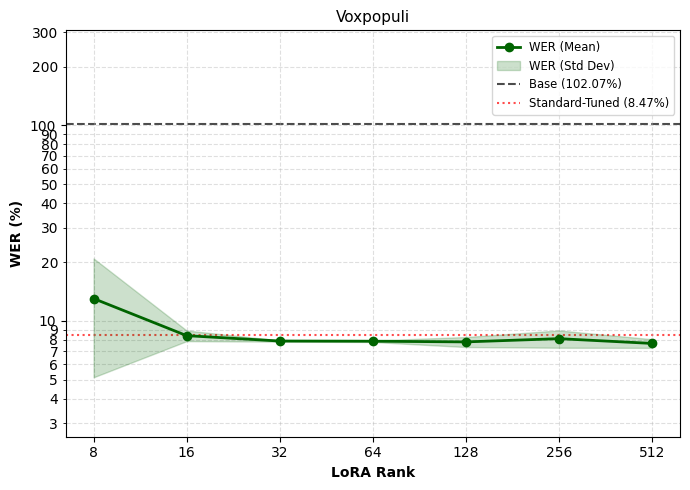

In [15]:
dataset_name = "voxpopuli"
plot_wer_lora_conf(
    df=df_lora_conf_agg,
    dataset_name=dataset_name,
    color="darkgreen",
    padding_rate=2,
    log_scale=True,
    metric_type="mean",
)

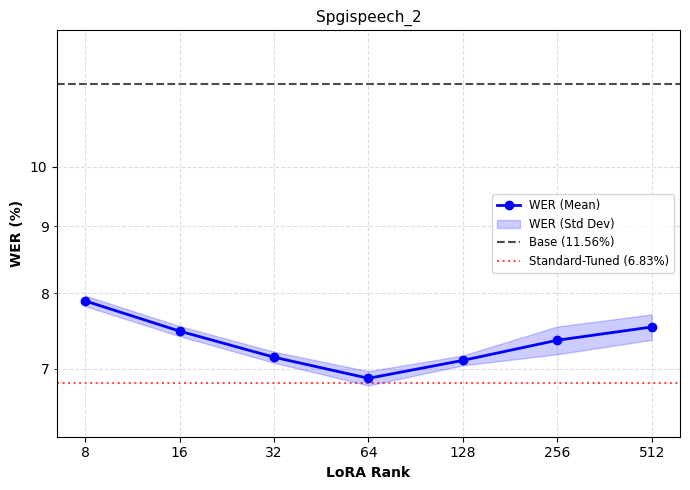

In [16]:
plot_wer_lora_conf(
    df=df_lora_conf_agg,
    dataset_name="spgispeech_2",
    padding_rate=0.10,
    log_scale=True,
    metric_type="mean",
)

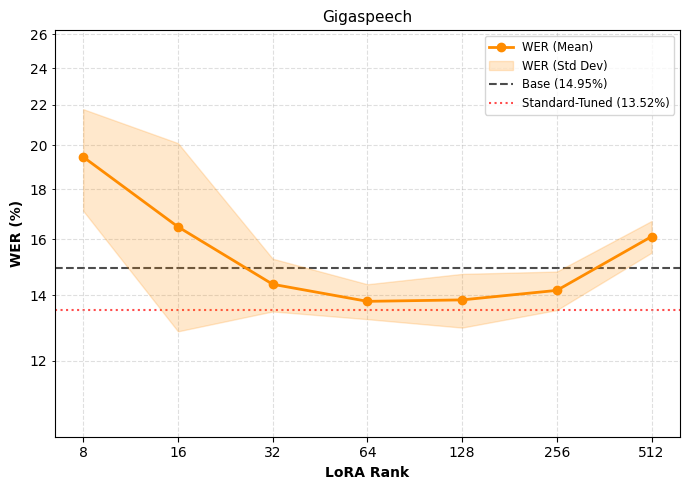

In [17]:
plot_wer_lora_conf(
    df=df_lora_conf_agg,
    dataset_name="gigaspeech",
    color="darkorange",
    padding_rate=0.35,
    log_scale=True,
    metric_type="mean",
)

###

## 2. Deeper Layers Training Results

In [ ]:
# def plot_deeper_layers_comparison(df, title="WER Comparison: Standard vs LoRA Fine-Tuning", log_scale=True, padding_rate=0.05):
#     """
#     Plots a line chart with fill-between for std.
#     Adds ±std labels on top of markers if std is non-zero.
#     """
#     # 1. Baseline Extraction
#     baseline_row = df[df["type"].str.lower() == "baseline"]
#     if not baseline_row.empty:
#         val = baseline_row["wer"].iloc[0]
#         baseline_wer = np.mean(val) if isinstance(val, (list, np.ndarray)) else val
#     else:
#         baseline_wer = None
        
#     # 2. Data Preparation
#     plot_df = df[df["type"].str.lower() != "baseline"].copy()
    
#     def sort_key(label):
#         label_str = str(label)
#         if label_str.startswith("L"):
#             try: return int(label_str[1:])
#             except: return 999
#         return 0
        
#     unique_labels = sorted(plot_df["label"].unique(), key=sort_key)
#     plot_df["label"] = pd.Categorical(plot_df["label"], categories=unique_labels, ordered=True)
    
#     exploded_df = plot_df.explode("wer")
#     exploded_df["wer"] = pd.to_numeric(exploded_df["wer"])
    
#     # 3. Plotting
#     plt.figure(figsize=(12, 7))
#     sns.set_style("whitegrid")
#     palette = {"standard": "#2E86C1", "lora": "#E67E22"}
    
#     ax = sns.lineplot(
#         data=exploded_df, 
#         x="label", 
#         y="wer", 
#         hue="type", 
#         marker="o", 
#         palette=palette,
#         linewidth=2.5,
#         markersize=8,
#         errorbar="sd"
#     )
    
#     # 4. Add ±std labels
#     stats = exploded_df.groupby(["label", "type"], observed=True)["wer"].agg(["mean", "std"]).reset_index()
    
#     for _, row in stats.iterrows():
#         if pd.notnull(row["std"]) and row["std"] > 1e-6:
#             # Map categorical label to its numeric index on the X-axis
#             x_pos = unique_labels.index(row["label"])
            
#             # Label positioning offset (needs to be relative for log scale)
#             y_offset = (row["mean"] + row["std"]) * 1.02 if log_scale else (row["mean"] + row["std"] + 0.0005)
            
#             plt.text(
#                 x=x_pos, 
#                 y=y_offset,
#                 s=f"±{row['std']:.4f}",
#                 ha='center', va='bottom', fontsize=9, fontweight='bold',
#                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
#             )
    
#     if baseline_wer is not None:
#         plt.axhline(y=baseline_wer, color="red", linestyle="--", label=f"Baseline: {baseline_wer:.4f}")
    
#     # 5. Scale and Limits (Fixed the undefined 'y' and 'padding_rate')
#     all_wer_values = exploded_df["wer"].dropna()
#     if baseline_wer is not None:
#         all_wer_values = pd.concat([all_wer_values, pd.Series([baseline_wer])])
        
#     y_min, y_max = all_wer_values.min(), all_wer_values.max()

#     if log_scale:
#         plt.yscale('log')
#         # Log padding: expand by percentage of the magnitude
#         plt.ylim(y_min / (1 + padding_rate), y_max * (1 + padding_rate))
#     else:
#         plt.ylim(y_min - (y_max * padding_rate), y_max + (y_max * padding_rate))
    
#     plt.title(title, fontsize=14, fontweight="bold", pad=15)
#     plt.ylabel("Word Error Rate (WER)", fontsize=11)
#     plt.xlabel("Layers Involved", fontsize=11)
#     plt.legend(title="Type", loc="upper center",bbox_to_anchor=(0.5, -0.15), ncol=3)
#     plt.tight_layout()
#     plt.show()

In [40]:
def plot_deeper_layers_comparison_optimized(df, title="WER Comparison: Standard vs LoRA Fine-Tuning", log_scale=True, padding_rate=0.05):
    # 1. Baseline Extraction
    baseline_row = df[df["type"].str.lower() == "baseline"]
    baseline_wer = None
    if not baseline_row.empty:
        val = baseline_row["wer"].iloc[0]
        baseline_wer = np.mean(val) if isinstance(val, (list, np.ndarray)) else val
        
    # 2. Data Preparation (Filter out baseline for the main lines)
    plot_df = df[df["type"].str.lower() != "baseline"].copy()
    
    def sort_key(label):
        label_str = str(label)
        if label_str.startswith("L"):
            try: return int(label_str[1:])
            except: return 999
        return 0
        
    unique_labels = sorted(plot_df["label"].unique(), key=sort_key)
    plot_df["label"] = pd.Categorical(plot_df["label"], categories=unique_labels, ordered=True)
    
    exploded_df = plot_df.explode("wer")
    exploded_df["wer"] = pd.to_numeric(exploded_df["wer"])
    
    # 3. Plotting
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    palette = {"standard": "#2E86C1", "lora": "#E67E22"}
    
    ax = sns.lineplot(
        data=exploded_df, 
        x="label", 
        y="wer", 
        hue="type", 
        marker="o", 
        palette=palette,
        linewidth=2.5,
        markersize=8,
        errorbar="sd"
    )
    
    # 4. Determine Y-Limits based ONLY on experimental data
    all_exp_values = exploded_df["wer"].dropna()
    y_min, y_max = all_exp_values.min(), all_exp_values.max()

    # Calculate View Limits
    if log_scale:
        plt.yscale('log')
        view_min = y_min / (1 + padding_rate)
        view_max = y_max * (1 + padding_rate)
    else:
        view_min = y_min - (y_max * padding_rate)
        view_max = y_max + (y_max * padding_rate)
    
    plt.ylim(view_min, view_max)

    # 5. Smart Baseline Handling
    if baseline_wer is not None:
        # If baseline is within or near the view, draw the line
        if baseline_wer <= view_max * 1.5:
            plt.axhline(y=baseline_wer, color="red", linestyle="--", alpha=0.6, label=f"Baseline: {baseline_wer:.2f}")
        else:
            # If baseline is an outlier, add a prominent text box instead
            plt.text(0.5, 0.96, f"OUTLIER BASELINE WER: {baseline_wer:.2f}", 
                     transform=ax.transAxes, color="red", fontweight="bold", 
                     ha="center", va="top", bbox=dict(facecolor='white', alpha=0.9, edgecolor='red'))

    # 6. Add ±std labels (mapped to categorical indices)
    stats = exploded_df.groupby(["label", "type"], observed=True)["wer"].agg(["mean", "std"]).reset_index()
    for _, row in stats.iterrows():
        if pd.notnull(row["std"]) and row["std"] > 1e-6:
            x_pos = list(unique_labels).index(row["label"])
            y_val = row["mean"] + row["std"]
            
            # Only draw label if it's within the visible Y-axis
            if y_val < view_max:
                y_offset = y_val * 1.02 if log_scale else y_val + (y_max * 0.01)
                plt.text(x_pos, y_offset, f"±{row['std']:.3f}", 
                         ha='center', va='bottom', fontsize=8, color="#555",
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5))

    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.ylabel("Word Error Rate (WER)", fontsize=11)
    plt.xlabel("Layers Involved", fontsize=11)
    
    # Legend handling: Place below the plot
    plt.legend(title="Model Type", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
    plt.tight_layout()
    plt.show()

In [19]:
accepted_experiment_ids = [
    "000",
    "001",
    "0023",
    "0030",
    "0031",
    "0040",
    "0041",
    "0050",
    "0051",
    "0060",
    "0061",
    "0070",
    "0071",
    "0080",
    "0081",
]
mask = (df_main["experiment_id"].isin(accepted_experiment_ids)) & \
       ((df_main["fraction"] == 1.0) | (df_main["fraction"].isna()))
df_deeper_ls = df_main[mask]

df_deeper_ls = df_deeper_ls.sort_values("wer",ascending=True)
group_cols = ['experiment_id', 'dataset', 'fraction', 'subset']
df_deeper_ls_best = df_deeper_ls.drop_duplicates(subset= group_cols, keep="first").reset_index(drop=True)
df_deeper_ls_best.tail()

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path
34,000,spgispeech_2,NaN,NaN,None,11.561548,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/000/results.json
35,0023,gigaspeech,1.0,0.0,42,13.033353,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/gigaspeech/002/0023/seed_42_frac_1....
36,001,gigaspeech,NaN,NaN,None,13.523135,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/001/001/results.json
37,000,gigaspeech,NaN,NaN,None,14.953090,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/000/inference_results/re...
38,000,voxpopuli,NaN,NaN,None,102.068661,0.951458,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/inference_results/res...


In [20]:
df_deeper_ls_logs = df_logs_main[
    df_logs_main["experiment_id"].isin(accepted_experiment_ids)
]
df_deeper_ls_logs = (
    df_deeper_ls_logs.drop_duplicates(subset="experiment_id")
    .drop("path", axis=1)
    .reset_index(drop=True)
)
df_deeper_ls_logs.tail()

,experiment_id,Trainable Parameters,All Parameters,Trainable %
8,0081,47664256,864631936,5.5127
9,0050,86701056,816967680,10.6100
10,0051,6792768,823760448,0.8246
11,001,53109760,816967680,6.5000
12,0041,5088832,822056512,0.6190


In [21]:
df_deeper_ls_final = pd.merge(
    df_deeper_ls_best, df_deeper_ls_logs, on="experiment_id", how="left"
)
df_deeper_ls_final["type"] = df_deeper_ls_final["experiment_id"].apply(
    lambda x: metadata.get(x, {}).get("type", "lora")
)
df_deeper_ls_final["label"] = df_deeper_ls_final[
    "experiment_id"
].apply(lambda x: metadata.get(x, {}).get("label", "L0"))
df_deeper_ls_final.tail()

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,Trainable Parameters,All Parameters,Trainable %,type,label
34,000,spgispeech_2,NaN,NaN,None,11.561548,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/000/results.json,0,816967680,0.0000,baseline,Baseline
35,0023,gigaspeech,1.0,0.0,42,13.033353,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/gigaspeech/002/0023/seed_42_frac_1....,3384896,820352576,0.4126,lora,L0
36,001,gigaspeech,NaN,NaN,None,13.523135,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/001/001/results.json,53109760,816967680,6.5000,standard,L0
37,000,gigaspeech,NaN,NaN,None,14.953090,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/000/inference_results/re...,0,816967680,0.0000,baseline,Baseline
38,000,voxpopuli,NaN,NaN,None,102.068661,0.951458,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/inference_results/res...,0,816967680,0.0000,baseline,Baseline


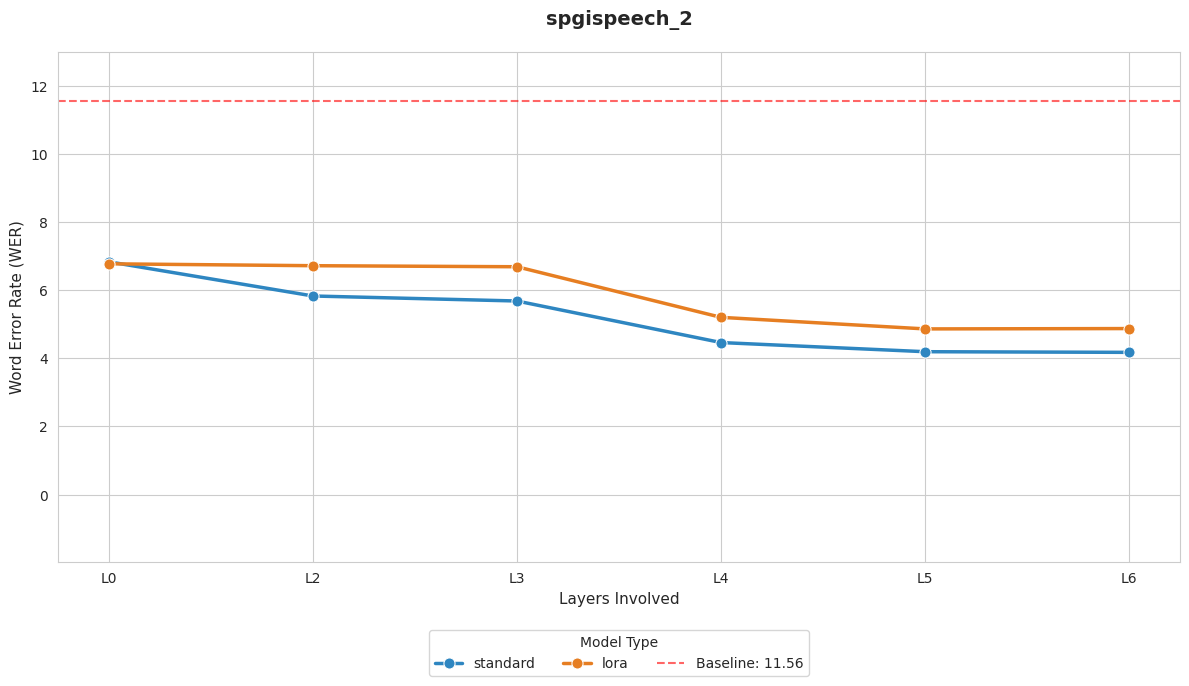

In [41]:
dataset_name = "spgispeech_2"
title=dataset_name
df_2_plot = df_deeper_ls_final[df_deeper_ls_final["dataset"]==dataset_name]
plot_deeper_layers_comparison_optimized(df_2_plot,padding_rate=.9,log_scale=False,title=title)

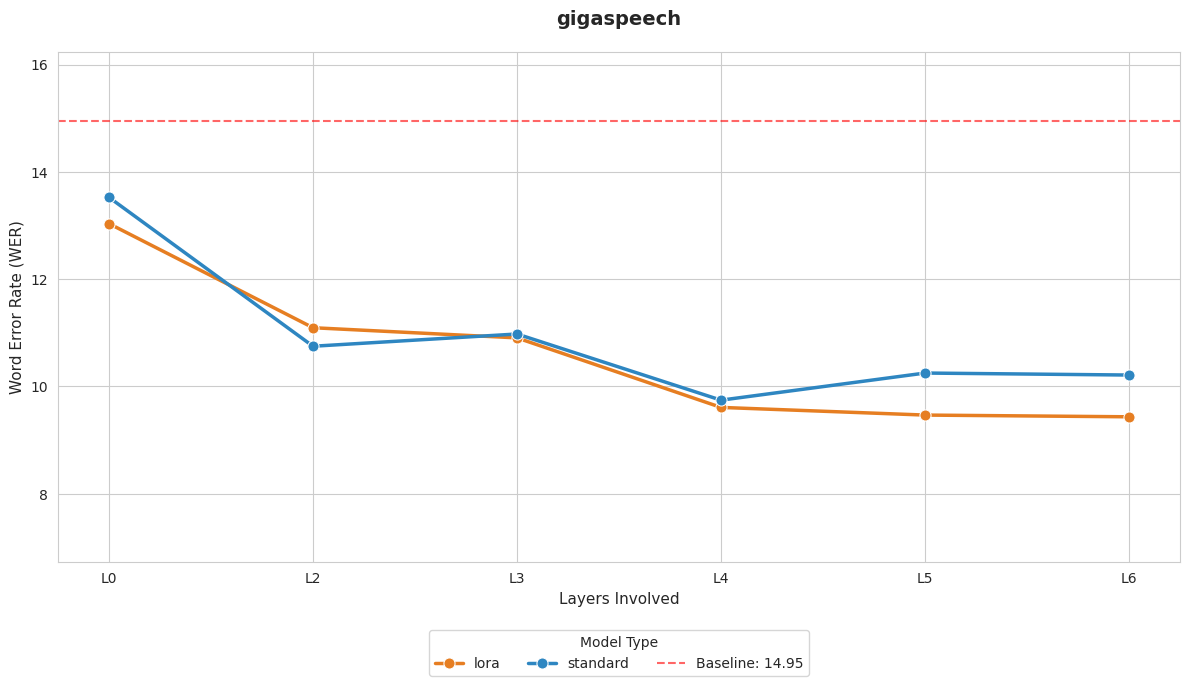

In [43]:
dataset_name = "gigaspeech"
title=dataset_name
df_2_plot = df_deeper_ls_final[df_deeper_ls_final["dataset"]==dataset_name]
plot_deeper_layers_comparison_optimized(df_2_plot,padding_rate=.2,log_scale=False,title=title)

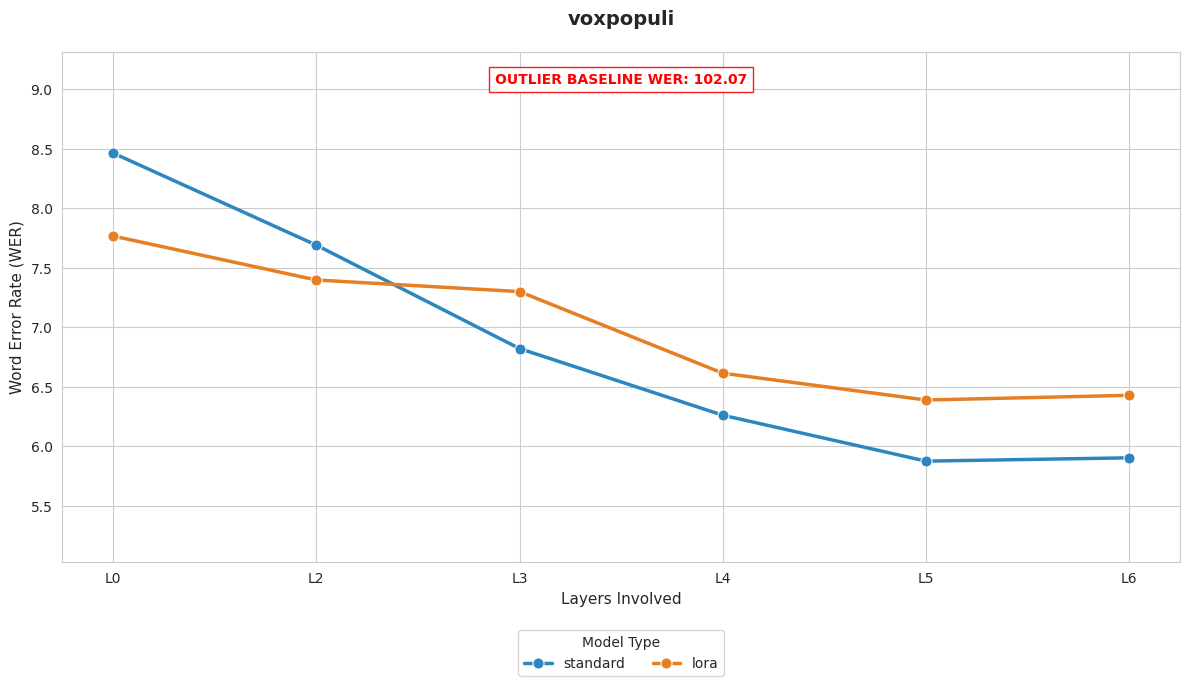

In [45]:
dataset_name = "voxpopuli"
title=dataset_name
df_2_plot = df_deeper_ls_final[df_deeper_ls_final["dataset"]==dataset_name]
plot_deeper_layers_comparison_optimized(df_2_plot,padding_rate=.1,log_scale=False,title=title)

In [13]:
spgi_paths = "/mnt/asr-data-scaling/outputs/spgispeech_2"
gigaspeech_paths = "/mnt/asr-data-scaling/outputs/gigaspeech"
voxpopuli_paths = "/mnt/asr-data-scaling/outputs/voxpopuli"

In [14]:
def load_results(dir_to_results):
    all_jsons = list(Path(dir_to_results).glob("**/results.json"))
    # Filtering logic: exclude 002 variants unless they are 0023
    all_jsons_filtered = [p for p in all_jsons if "002" not in str(p) or "0023" in str(p)]
    
    # Group results by run_id to handle multiple seeds
    grouped_data = {}
    
    for p in all_jsons_filtered:
        with open(p, "r") as f:
            data = json.load(f)
        
        if "voxpopuli" in str(p):
            wer =  data["metrics"]["voxpopuli-en"]["wer"]
        else:
            wer = data.get("metrics", {}).get("wer")
            time = data.get("training_time",None)
        
        if wer is None:
            continue
            
        # Determine the grouped run_id
        if "0023" in str(p):
            run_id = "002"
        elif "000" in str(p):
            run_id = "000"
        elif "001" in str(p):
            run_id = "001"
        else:
            try:
                run_id = re.findall(r'\b\d{4,5}\b', str(p))[0]
            except:
                print(p)
            
            
        if run_id not in grouped_data:
            grouped_data[run_id] = {"wers": [], "times": []}
            
        grouped_data[run_id]["wers"].append(wer)
        # if time is not None:
        #     grouped_data[run_id]["times"].append(time)
            
    results = []
    for run_id, values in grouped_data.items():
        # Return the accumulated lists directly without aggregation
        results.append({
            "id": run_id,
            "wer": values["wers"],
            # "training_time": values["times"]
        })
        
    return results

In [15]:
gigaspeech_results = load_results(gigaspeech_paths)
gigaspeech_results

[{'id': '0070', 'wer': [0.10247517025930945]},
 {'id': '0071',
  'wer': [0.09553845048544651,
   0.09495378410450664,
   0.09463915431476357,
   0.09599181467066684,
   0.09595713107179753]},
 {'id': '0041', 'wer': [0.11092558138382605]},
 {'id': '0040', 'wer': [0.10747208589641]},
 {'id': '0060', 'wer': [0.09741879702414721]},
 {'id': '0061', 'wer': [0.09606861406816318]},
 {'id': '000', 'wer': [0.1495309043252925]},
 {'id': '002',
  'wer': [0.13509757239581913,
   0.13955936965036456,
   0.1397575616439035,
   0.14559927065346379,
   0.13033353235112685]},
 {'id': '0080', 'wer': [0.10210356027142393]},
 {'id': '0081',
  'wer': [0.0943170923252628,
   0.09590262827357432,
   0.09463172211500585,
   0.09676476344546871,
   0.09576389387809706]},
 {'id': '0050', 'wer': [0.1097562486219463]},
 {'id': '0051', 'wer': [0.10919387884027955]},
 {'id': '001', 'wer': [0.13523135199145792]}]

In [16]:
gigaspeech_results = load_results(gigaspeech_paths)
gigaspeech_df = pd.DataFrame(gigaspeech_results)
gigaspeech_df

,id,wer
0,0070,[0.10247517025930945]
1,0071,"[0.09553845048544651, 0.09495378410450664, 0.0..."
2,0041,[0.11092558138382605]
3,0040,[0.10747208589641]
4,0060,[0.09741879702414721]
5,0061,[0.09606861406816318]
6,000,[0.1495309043252925]
7,002,"[0.13509757239581913, 0.13955936965036456, 0.1..."
8,0080,[0.10210356027142393]
9,0081,"[0.0943170923252628, 0.09590262827357432, 0.09..."


In [17]:
experiment_types = {
    "000": {"label": "Baseline", "type": "baseline"},
    "001": {"label": "L0", "type": "standard"},
    
    # L0 Experiments (002*)
    "002": {"label": "L0", "type": "lora"},

    # L1 Experiments (003*) - Skipped
    "0030": {"label": "L1", "type": "standard"},
    "0031": {"label": "L1", "type": "lora"},

    # L2 Experiments (004*)
    "0040": {"label": "L2", "type": "standard"},
    "0041": {"label": "L2", "type": "lora"},

    # L3 Experiments (005*)
    "0050": {"label": "L3", "type": "standard"},
    "0051": {"label": "L3", "type": "lora"},

    # L4 Experiments (006*)
    "0060": {"label": "L4", "type": "standard"},
    "0061": {"label": "L4", "type": "lora"},

    # L5 Experiments (007*)
    "0070": {"label": "L5", "type": "standard"},
    "0071": {"label": "L5", "type": "lora"},

    # L6 Experiments (008*)
    "0080": {"label": "L6", "type": "standard"},
    "0081": {"label": "L6", "type": "lora"},
}

In [18]:
experiment_types_df = pd.DataFrame(experiment_types).T.reset_index().rename(columns={"index": "id"})
experiment_types_df

,id,label,type
0,000,Baseline,baseline
1,001,L0,standard
2,002,L0,lora
3,0030,L1,standard
4,0031,L1,lora
5,0040,L2,standard
6,0041,L2,lora
7,0050,L3,standard
8,0051,L3,lora
9,0060,L4,standard


In [19]:
df_gigaspeech_results_total = pd.merge(gigaspeech_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  
df_gigaspeech_results_total

,id,wer,label,type
0,000,[0.1495309043252925],Baseline,baseline
1,001,[0.13523135199145792],L0,standard
2,002,"[0.13509757239581913, 0.13955936965036456, 0.1...",L0,lora
3,0040,[0.10747208589641],L2,standard
4,0041,[0.11092558138382605],L2,lora
5,0050,[0.1097562486219463],L3,standard
6,0051,[0.10919387884027955],L3,lora
7,0060,[0.09741879702414721],L4,standard
8,0061,[0.09606861406816318],L4,lora
9,0070,[0.10247517025930945],L5,standard


In [36]:
def plot_wer_comparison(df, title="WER Comparison: Standard vs LoRA Fine-Tuning", log_scale=True, padding_rate=0.05):
    """
    Plots a line chart with fill-between for std.
    Adds ±std labels on top of markers if std is non-zero.
    """
    # 1. Baseline Extraction
    baseline_row = df[df["type"].str.lower() == "baseline"]
    if not baseline_row.empty:
        val = baseline_row["wer"].iloc[0]
        baseline_wer = np.mean(val) if isinstance(val, (list, np.ndarray)) else val
    else:
        baseline_wer = None
        
    # 2. Data Preparation
    plot_df = df[df["type"].str.lower() != "baseline"].copy()
    
    def sort_key(label):
        label_str = str(label)
        if label_str.startswith("L"):
            try: return int(label_str[1:])
            except: return 999
        return 0
        
    unique_labels = sorted(plot_df["label"].unique(), key=sort_key)
    plot_df["label"] = pd.Categorical(plot_df["label"], categories=unique_labels, ordered=True)
    
    exploded_df = plot_df.explode("wer")
    exploded_df["wer"] = pd.to_numeric(exploded_df["wer"])
    
    # 3. Plotting
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    palette = {"standard": "#2E86C1", "lora": "#E67E22"}
    
    ax = sns.lineplot(
        data=exploded_df, 
        x="label", 
        y="wer", 
        hue="type", 
        marker="o", 
        palette=palette,
        linewidth=2.5,
        markersize=8,
        errorbar="sd"
    )
    
    # 4. Add ±std labels
    stats = exploded_df.groupby(["label", "type"], observed=True)["wer"].agg(["mean", "std"]).reset_index()
    
    for _, row in stats.iterrows():
        if pd.notnull(row["std"]) and row["std"] > 1e-6:
            # Map categorical label to its numeric index on the X-axis
            x_pos = unique_labels.index(row["label"])
            
            # Label positioning offset (needs to be relative for log scale)
            y_offset = (row["mean"] + row["std"]) * 1.02 if log_scale else (row["mean"] + row["std"] + 0.0005)
            
            plt.text(
                x=x_pos, 
                y=y_offset,
                s=f"±{row['std']:.4f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )
    
    if baseline_wer is not None:
        plt.axhline(y=baseline_wer, color="red", linestyle="--", label=f"Baseline: {baseline_wer:.4f}")
    
    # 5. Scale and Limits (Fixed the undefined 'y' and 'padding_rate')
    all_wer_values = exploded_df["wer"].dropna()
    if baseline_wer is not None:
        all_wer_values = pd.concat([all_wer_values, pd.Series([baseline_wer])])
        
    y_min, y_max = all_wer_values.min(), all_wer_values.max()

    if log_scale:
        plt.yscale('log')
        # Log padding: expand by percentage of the magnitude
        plt.ylim(y_min / (1 + padding_rate), y_max * (1 + padding_rate))
    else:
        plt.ylim(y_min - (y_max * padding_rate), y_max + (y_max * padding_rate))
    
    plt.title(title, fontsize=14, fontweight="bold", pad=15)
    plt.ylabel("Word Error Rate (WER)", fontsize=11)
    plt.xlabel("Layers Involved", fontsize=11)
    plt.legend(title="Type", loc="upper center",bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()
    plt.show()

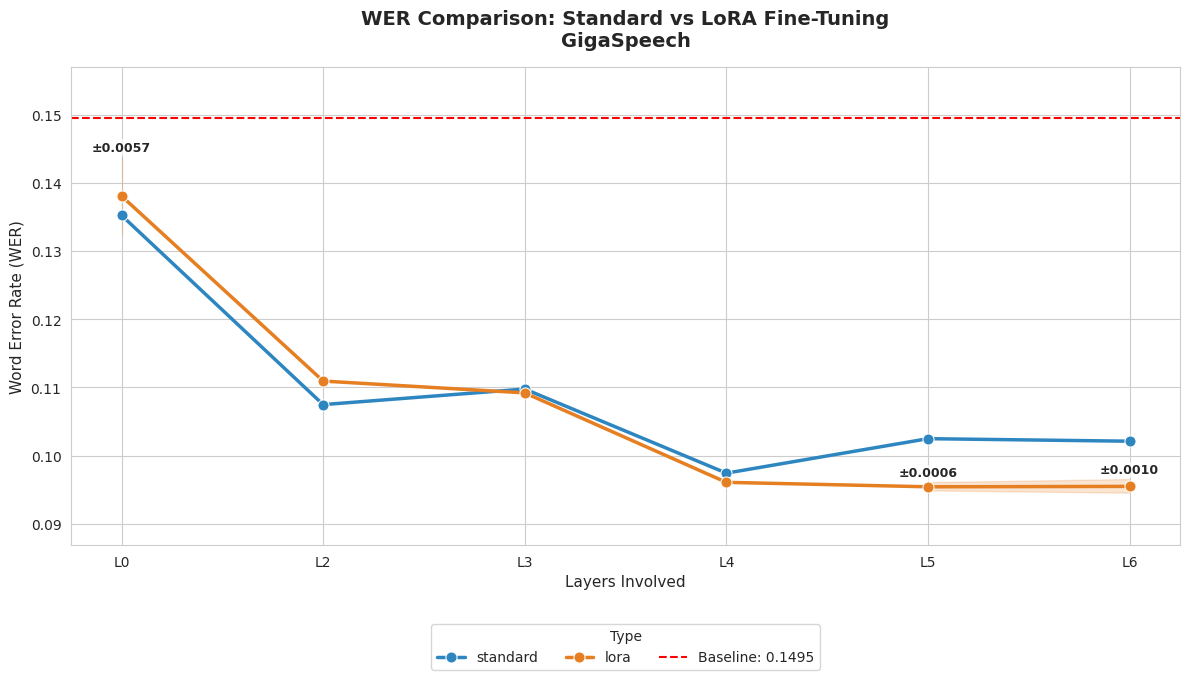

In [37]:
plot_wer_comparison(df_gigaspeech_results_total,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nGigaSpeech",log_scale=False)

In [22]:
spgispeech_results = load_results(spgi_paths)
spgispeech_results

[{'id': '000', 'wer': [0.11561548195786905]},
 {'id': '0070', 'wer': [0.0419323206377262]},
 {'id': '0071', 'wer': [0.04862135291784376]},
 {'id': '0041', 'wer': [0.06716947756044377]},
 {'id': '0040', 'wer': [0.05828067729211338]},
 {'id': '0060', 'wer': [0.04461847306619457]},
 {'id': '0061', 'wer': [0.05201749844577739]},
 {'id': '002',
  'wer': [0.06878245085060307,
   0.06772493856102843,
   0.06898042284824735,
   0.07013051197125275,
   0.06859800931322944]},
 {'id': '0080', 'wer': [0.04173933354649743]},
 {'id': '0081', 'wer': [0.0487203389166659]},
 {'id': '0050', 'wer': [0.05681155415851575]},
 {'id': '0051', 'wer': [0.06934503314606702]},
 {'id': '001', 'wer': [0.06831163596562129]}]

In [38]:
spgispeech_2_df = pd.DataFrame(spgispeech_results)
spgispeech_2_df

,id,wer
0,000,[0.11561548195786905]
1,0070,[0.0419323206377262]
2,0071,[0.04862135291784376]
3,0041,[0.06716947756044377]
4,0040,[0.05828067729211338]
5,0060,[0.04461847306619457]
6,0061,[0.05201749844577739]
7,002,"[0.06878245085060307, 0.06772493856102843, 0.0..."
8,0080,[0.04173933354649743]
9,0081,[0.0487203389166659]


In [24]:
spgispeech_2_df_total = pd.merge(spgispeech_2_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  
spgispeech_2_df_total

,id,wer,label,type
0,000,[0.11561548195786905],Baseline,baseline
1,001,[0.06831163596562129],L0,standard
2,002,"[0.06878245085060307, 0.06772493856102843, 0.0...",L0,lora
3,0040,[0.05828067729211338],L2,standard
4,0041,[0.06716947756044377],L2,lora
5,0050,[0.05681155415851575],L3,standard
6,0051,[0.06934503314606702],L3,lora
7,0060,[0.04461847306619457],L4,standard
8,0061,[0.05201749844577739],L4,lora
9,0070,[0.0419323206377262],L5,standard


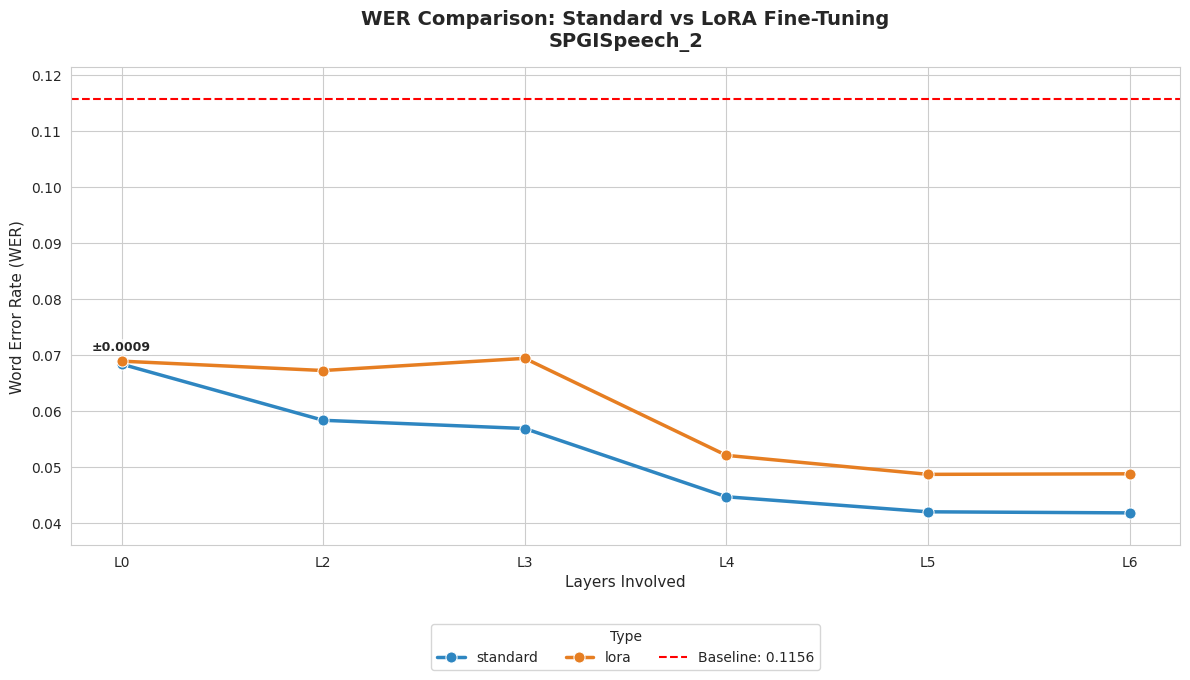

In [39]:
plot_wer_comparison(spgispeech_2_df_total,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nSPGISpeech_2",log_scale=False)

In [26]:
voxpopuli_results = load_results(voxpopuli_paths)
voxpopuli_df = pd.DataFrame(voxpopuli_results)
voxpopuli_df_total = pd.merge(voxpopuli_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  

voxpopuli_df_total

,id,wer,label,type
0,000,[1.0206866094879483],Baseline,baseline
1,001,[0.08465239523045813],L0,standard
2,002,"[0.07767938079631825, 0.07902749692025196, 0.0...",L0,lora
3,0050,[0.06821932454733515],L3,standard
4,0051,[0.07300746112544453],L3,lora
5,0060,[0.06261766961857611],L4,standard
6,0061,[0.06615066359854031],L4,lora
7,0070,[0.05875926829835204],L5,standard
8,0071,[0.06389605559816842],L5,lora
9,0080,[0.05903818887571764],L6,standard


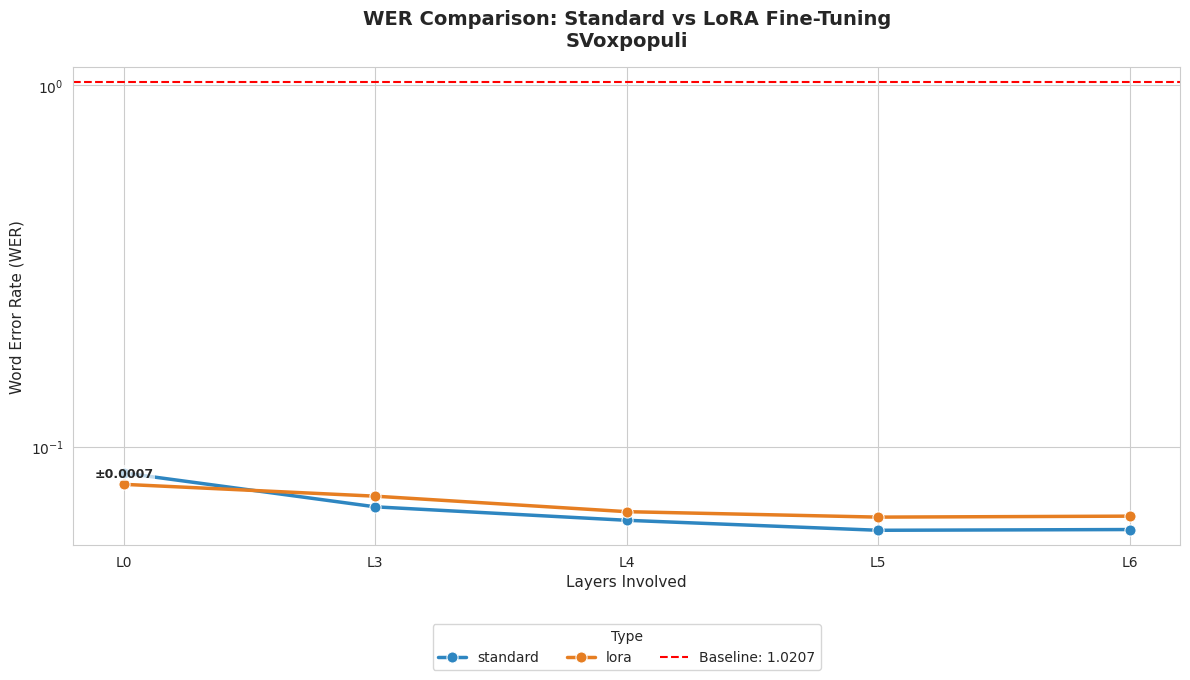

In [42]:
plot_wer_comparison(voxpopuli_df_total,padding_rate=.1,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nSVoxpopuli")

### Optimising 0070 with layer-specific dropout

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns
from pathlib import Path
import re
import json

In [3]:
# 1. Get all json paths
all_jsons_paths = list(Path("../outputs/gigaspeech/007").glob("**/results.json"))
# 2. Load the jsons into memory
all_jsons = [json.load(open(j)) for j in all_jsons_paths]
# 3. Update each dictionary with the new key (using a fast loop instead of list comprehension)
for item in all_jsons:
    item['exp_id'] = item['model_path'].split("/")[-2]
    try:
        item["wer"] = item["metrics"]["speechcolab-gigaspeech-m"]["wer"]
    except KeyError:
        item["wer"] = item["metrics"]["wer"]
df_007 = pd.DataFrame(all_jsons)
df_007 = df_007.groupby("exp_id").agg({"wer": "mean"}).reset_index()
df_007


,exp_id,wer
0,0070,0.102475
1,00701-d,0.100466
2,00702-d,0.100600
3,00703-d,0.100134
4,00704-d,0.099366
5,00705-d,0.103194
6,00706-d,0.100424
7,00707-d,0.099205
8,00708-d,0.100149
9,0071,0.095416


In [4]:
hyperparameters_list = [
    {"exp_id": "0070",   "dropout": 0.0, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.0,"type":"base"},
    {"exp_id": "00701-d", "dropout": 0.1, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00702-d", "dropout": 0.5, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00703-d", "dropout": 0.1, "attention_dropout": 0.1, "activation_dropout": 0.1, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00704-d", "dropout": 0.2, "attention_dropout": 0.2, "activation_dropout": 0.2, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00705-d", "dropout": 0.2, "attention_dropout": 0.5, "activation_dropout": 0.5, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00706-d", "dropout": 0.3, "attention_dropout": 0.3, "activation_dropout": 0.3, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00707-d", "dropout": 0.15, "attention_dropout": 0.15, "activation_dropout": 0.15, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00708-d", "dropout": 0.25, "attention_dropout": 0.25, "activation_dropout": 0.25, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "0071", "dropout": 0.0, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.0,"type":"lora"},
]
df_hyp = pd.DataFrame(hyperparameters_list)
df_hyp

,exp_id,dropout,attention_dropout,activation_dropout,weight_decay,type
0,0070,0.00,0.00,0.00,0.0,base
1,00701-d,0.10,0.00,0.00,0.1,base
2,00702-d,0.50,0.00,0.00,0.1,base
3,00703-d,0.10,0.10,0.10,0.1,base
4,00704-d,0.20,0.20,0.20,0.1,base
5,00705-d,0.20,0.50,0.50,0.1,base
6,00706-d,0.30,0.30,0.30,0.1,base
7,00707-d,0.15,0.15,0.15,0.1,base
8,00708-d,0.25,0.25,0.25,0.1,base
9,0071,0.00,0.00,0.00,0.0,lora


In [5]:
df_all = pd.merge(df_007,df_hyp,on="exp_id")
df_all

,exp_id,wer,dropout,attention_dropout,activation_dropout,weight_decay,type
0,0070,0.102475,0.00,0.00,0.00,0.0,base
1,00701-d,0.100466,0.10,0.00,0.00,0.1,base
2,00702-d,0.100600,0.50,0.00,0.00,0.1,base
3,00703-d,0.100134,0.10,0.10,0.10,0.1,base
4,00704-d,0.099366,0.20,0.20,0.20,0.1,base
5,00705-d,0.103194,0.20,0.50,0.50,0.1,base
6,00706-d,0.100424,0.30,0.30,0.30,0.1,base
7,00707-d,0.099205,0.15,0.15,0.15,0.1,base
8,00708-d,0.100149,0.25,0.25,0.25,0.1,base
9,0071,0.095416,0.00,0.00,0.00,0.0,lora


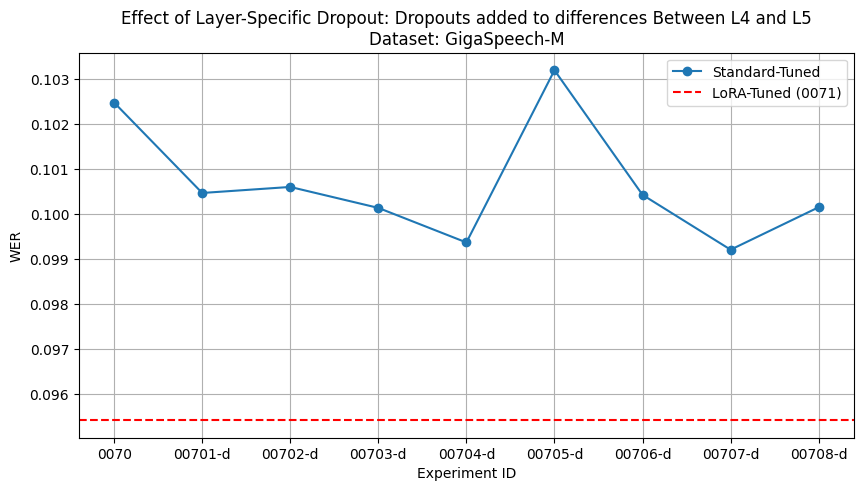

In [8]:
fig,ax = plt.subplots(1,1,figsize=(10,5))
x = df_all[df_all["type"]=="base"]["exp_id"]
y = df_all[df_all["type"]=="base"]["wer"]
ax.plot(x,y,marker="o")
lora_wer = df_all[df_all["type"]=="lora"]['wer'].values[0]
lora_exp_id = df_all[df_all["type"]=="lora"]['exp_id'].values[0]
# 2. Draw the horizontal line
ax.axhline(lora_wer, color="r", linestyle="--")
# # 3. Add the exp_id as text at the y-coordinate of the line
# ax.text(7.5, lora_wer+.0002, f' {lora_exp_id}', color="red", va='bottom', ha='left')
ax.set_title("Effect of Layer-Specific Dropout: Dropouts added to differences Between L4 and L5\nDataset: GigaSpeech-M")
ax.set_xlabel("Experiment ID")
ax.set_ylabel("WER")
plt.legend(["Standard-Tuned","LoRA-Tuned (0071)"])
ax.grid(True)
plt.show()


In [53]:
df_all[df_all["type"]=="lora"]['wer'].values[0]

0.09541606692943622

## Data Scaling Results 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import re

## Stress test with 5% on L0 and half of training steps

In [2]:
results_dir = "/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023"
all_res_paths = list(Path(results_dir).glob("**/results.json"))
baseline_res_path = Path("/mnt/asr-data-scaling/outputs/spgispeech_2/000/results.json")
all_res_paths = all_res_paths + [baseline_res_path]
all_res_paths

[PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_123_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_123456_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_12345_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_1234_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_42_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_scaling_frac_0.05_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_scaling_frac_0.05_subset_4/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_scaling_frac_0.05_subset_3/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_sca

In [3]:
def parse_results_file(file_path, dataset_name):
    """
    Parses a results.json file to extract the experiment ID, data fraction, and WER.
    
    Args:
        file_path (str or Path): The path to the results.json file.
        dataset_name (str): The dataset name, used for looking up nested WER and path splitting.
        
    Returns:
        dict: A dictionary containing 'experiment_id', 'fraction', and 'wer'.
    """
    file_path_obj = Path(file_path)
    path_str = str(file_path_obj)
    
    # 1. Extract Fraction from the parent directory's name
    try:
        # Example parent name: 'data_scaling_frac_0.05_subset_4'
        fraction_str = file_path_obj.parent.name.split('frac_')[1].split('_')[0]
        fraction = float(fraction_str)
    except IndexError:
        fraction = None
        
    # 2. Extract Experiment ID using a flexible regular expression
    # This safely catches both single IDs ("0023") or nested IDs ("002/0023") matching just directories with digits
    exp_id_match = re.search(rf"{dataset_name}/((?:\d+/)*\d+)", path_str)
    experiment_id = exp_id_match.group(1) if exp_id_match else None
        
    # 3. Read the JSON to extract WER
    with open(file_path_obj, 'r') as f:
        data = json.load(f)
        
    metrics = data.get("metrics", {})
    wer = None
    
    # Handle Case 1: 'wer' is directly inside metrics
    if "wer" in metrics:
        wer = metrics["wer"]
    # Handle Case 2: 'wer' is nested inside the dataset name dictionary
    elif dataset_name in metrics and "wer" in metrics[dataset_name]:
        wer = metrics[dataset_name]["wer"]
    # Fallback Case: Search for any nested dictionary that has 'wer' just in case
    else:
        for key, value in metrics.items():
            if isinstance(value, dict) and "wer" in value:
                wer = value["wer"]
                break

    if "half" in str(file_path):
        steps= "50% steps"
    else:
        steps = "100% steps"

    if experiment_id =="000":
        steps = None

    is_repeat = "no"
    if "repeat" in str(file_path):
        is_repeat = "yes"
    
    match = re.search(r"subset_(\d+)", str(file_path))
    if match:
        subset = match.group(1)
    else:
        subset = None

    return {
        "experiment_id": experiment_id,
        "fraction": fraction,
        "wer": wer,
        "steps":steps,
        "is_repeat":is_repeat,
        "data_subset":subset
    }

In [4]:
all_results = []
dataset_name = 'spgispeech_2'
for p in all_res_paths:
    res = parse_results_file(p,dataset_name)
    all_results.append(res) 

df = pd.DataFrame(all_results)
df

,experiment_id,fraction,wer,steps,is_repeat,data_subset
0,002/0023,1.00,0.068782,100% steps,no,0
1,002/0023,1.00,0.067725,100% steps,no,0
2,002/0023,1.00,0.068980,100% steps,no,0
3,002/0023,1.00,0.070131,100% steps,no,0
4,002/0023,1.00,0.068598,100% steps,no,0
5,002/0023,0.05,0.077861,100% steps,no,1
6,002/0023,0.05,0.078886,100% steps,no,4
7,002/0023,0.05,0.078908,100% steps,no,3
8,002/0023,0.05,0.078037,100% steps,no,0
9,002/0023,0.05,0.079333,100% steps,no,2


In [5]:
def plot_wer_results(df):
    """
    Plots a line graph of WER with combined experiment_id and repetition on the X-axis 
    for scaled data (fractions < 1.0).
    Adds two horizontal lines:
    1: The baseline '000' run.
    2: The mean WER of the fraction 1.0 runs.
    """
    plot_df = df.copy()
    
    # 1. Identify and extract the vanilla baseline (experiment_id == '000')
    baseline_rows = plot_df[plot_df['experiment_id'] == '000']
    vanilla_wer = None
    if not baseline_rows.empty:
        vanilla_wer = baseline_rows['wer'].iloc[0]
        
    # 2. Identify and calculate the mean for the Fraction 1.0 baseline
    # Ensure fraction is treated as a numeric value for checking 1.0
    plot_df['fraction_num'] = pd.to_numeric(plot_df['fraction'], errors='coerce')
    frac_1_rows = plot_df[plot_df['fraction_num'] == 1.0]
    
    frac_1_mean_wer = None
    if not frac_1_rows.empty:
        frac_1_mean_wer = frac_1_rows['wer'].mean()
        
    # 3. Remove the vanilla baseline and the 1.0 fraction runs from the line plotting dataframe
    plot_df = plot_df[(plot_df['experiment_id'] != '000') & (plot_df['fraction_num'] != 1.0)].copy()
    
    # 4. Add a 'repetition' column for the remaining data
    plot_df['repetition'] = plot_df.groupby(['experiment_id','steps', 'fraction']).cumcount() + 1
    
    # 5. Combine Experiment ID and Repetition for the X-axis label
    # BUG FIX 1: Added `plot_df['experiment_id']` mapping to the string layout.
    plot_df['x_axis_label'] = " (Rep " + plot_df['repetition'].astype(str) + ")"
    
    # Ensure fraction is a string for categorical legend coloring
    plot_df['fraction'] = plot_df['fraction'].astype(str)
    
    # 6. Create the plot
    plt.figure(figsize=(10, 6))
    
    # Draw the main line(s) for the scaled fractions (e.g. 0.05)
    if not plot_df.empty:
        sns.lineplot(
            data=plot_df[plot_df["steps"].isin(["100% steps", "50% steps"])], 
            x='x_axis_label', 
            y='wer', 
            # BUG FIX 2: Used `steps` for `hue` effectively to utilize your defined palette safely.
            hue='steps', 
            # style='fraction',
            marker='o',
            palette={
                "100% steps": "blue",
                "50% steps": "red"
            },
            linewidth=2,
            markersize=8,

        )

    # 7. Add the Horizontal Line for the Vanilla Baseline (000)
    if vanilla_wer is not None:
        plt.axhline(
            y=vanilla_wer, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label=f"Vanilla (000) (WER: {vanilla_wer:.4f})"
        )
        
    # 8. Add the Horizontal Line for the Mean of Fraction 1.0
    if frac_1_mean_wer is not None:
        plt.axhline(
            y=frac_1_mean_wer, 
            color='green', 
            linestyle='-.', 
            linewidth=2, 
            label=f"Fraction 1.0 Mean (WER: {frac_1_mean_wer:.4f})"
        )

    frac_05_rows = plot_df[plot_df['fraction_num'] == 0.05]
    
    if not frac_05_rows.empty:
        mean_wer_by_steps=frac_05_rows.groupby('steps')['wer'].mean()

    text_lines = ["Mean WER (Fraction 0.05):"]
    for step_name, mean_val in mean_wer_by_steps.items():
        text_lines.append(f"  {step_name}: {mean_val:.4f}")
        
    text_box_str = "\n".join(text_lines)
    
    # Add the text box to the top-left of the plot
    plt.text(
        0.02, 0.76,  # X, Y coordinates
        text_box_str,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    )
        
    # 9. Formatting the plot
    # BUG FIX 3: Fixed typo "Fine-tuining" to "Fine-tuning"
    plt.title('WER by Experiment Repetition and Data Fraction\nFine-tuning L0 (Proj_out layer)', fontsize=14)
    plt.xlabel('Experiment ID and Repetition', fontsize=12)
    plt.ylabel('Word Error Rate (WER)', fontsize=12)
    
    # Uncommented and positioned properly 
    plt.xticks(rotation=0, ha='right')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Combine legends to show both the horizontal lines and the fraction categories
    plt.legend(
        title='Baselines & Data Fractions',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.25), # Adjusted slightly lower because of the x-tick rotation
        ncol=2
    )
    plt.tight_layout()
    
    plt.show()


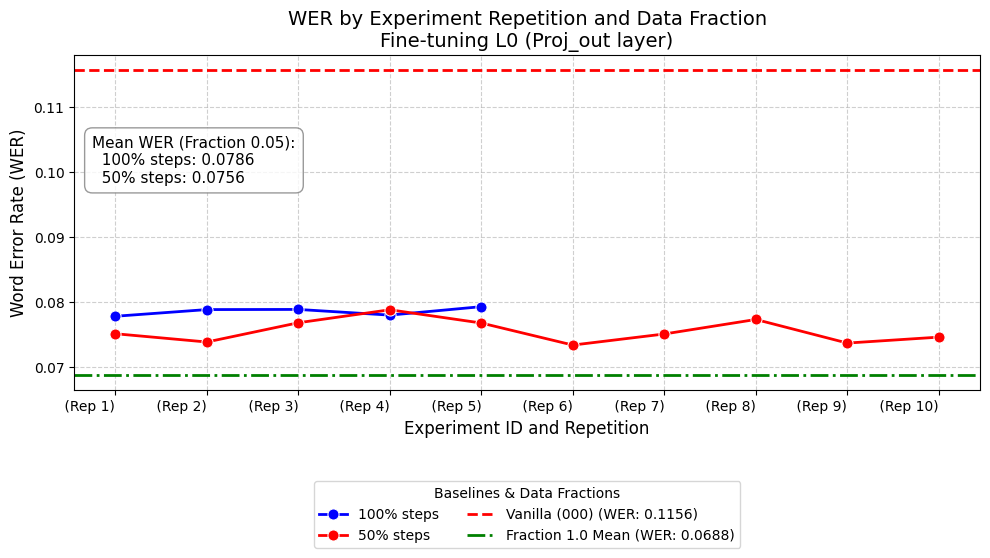

In [6]:
plot_wer_results(df)

In [7]:
def plot_wer_bar_chart(df):
    """
    Plots a bar chart of WER for fraction 0.05 across data subsets.
    Groups: 100% steps, 50% steps (Rep 1), 50% steps (Rep 2).
    Includes horizontal lines for Vanilla (000) and Fraction 1.0 Mean.
    Sorts 'data_subset' numerically on the X-axis.
    """
    df_copy = df.copy()
    
    # --- 1. EXTRACT BASELINES FROM FULL DATA FIRST ---
    # Ensure necessary columns are numeric
    df_copy['fraction_num'] = pd.to_numeric(df_copy['fraction'], errors='coerce')
    df_copy['wer'] = pd.to_numeric(df_copy['wer'], errors='coerce')
    df_copy['data_subset'] = pd.to_numeric(df_copy['data_subset'], errors='coerce')

    # Identify vanilla baseline (experiment_id == '000')
    baseline_rows = df_copy[df_copy['experiment_id'] == '000']
    vanilla_wer = None
    if not baseline_rows.empty:
        vanilla_wer = baseline_rows['wer'].iloc[0]
        
    # Calculate mean for Fraction 1.0 baseline
    frac_1_rows = df_copy[df_copy['fraction_num'] == 1.0]
    frac_1_mean_wer = None
    if not frac_1_rows.empty:
        frac_1_mean_wer = frac_1_rows['wer'].mean()

    # --- 2. FILTER & SORT FOR BAR CHART DATA (0.05 FRACTION) ---
    plot_df = df_copy[df_copy['fraction_num'] == 0.05].copy()
    
    if plot_df.empty:
        print("No data found for fraction 0.05")
        return

    # Sort numerically by data_subset for a logical progression on X-axis
    plot_df = plot_df.sort_values('data_subset')

    # --- 3. DEFINE CATEGORICAL GROUPING ---
    def categorize(row):
        if str(row['steps']) == '100% steps':
            return '100% steps'
        elif str(row['steps']) == '50% steps':
            repeat_val = str(row['is_repeat']).lower().strip()
            if repeat_val == 'no':
                return '50% steps (Rep 1)'
            elif repeat_val == 'yes':
                return '50% steps (Rep 2)'
        return None

    plot_df['experiment_group'] = plot_df.apply(categorize, axis=1)
    plot_df = plot_df.dropna(subset=['experiment_group'])

    # --- 4. CREATE THE PLOT ---
    plt.figure(figsize=(12, 9))
    sns.barplot(
        data=plot_df,
        x='data_subset',
        y='wer',
        hue='experiment_group',
        palette={
            '100% steps': '#4C72B0',           # Blue
            '50% steps (Rep 1)': '#DD8452',    # Orange
            '50% steps (Rep 2)': '#55A868',     # Green

        },
        zorder=3
    )

    # Add Vanilla (000) baseline line
    if vanilla_wer is not None:
        plt.axhline(
            y=vanilla_wer, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label=f"Vanilla (000) (WER: {vanilla_wer:.4f})"
        )
        
    # Add Fraction 1.0 Mean baseline line
    if frac_1_mean_wer is not None:
        plt.axhline(
            y=frac_1_mean_wer, 
            color='black', 
            linestyle='-.', 
            linewidth=2, 
            label=f"Fraction 1.0 Mean (WER: {frac_1_mean_wer:.4f})",
            zorder=4
        )

    # --- 5. FORMATTING & LEGEND ---
    plt.title('WER Comparison for Data Fraction 0.05\n(100% Steps vs 50% Steps with/without Repeat)', fontsize=14)
    plt.xlabel('Data Subset', fontsize=12)
    plt.ylabel('Word Error Rate (WER)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Legend position tweaked for better visibility
    plt.legend(
        title='Baselines & Configurations',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=2
    )
    
    plt.tight_layout()
    plt.show()


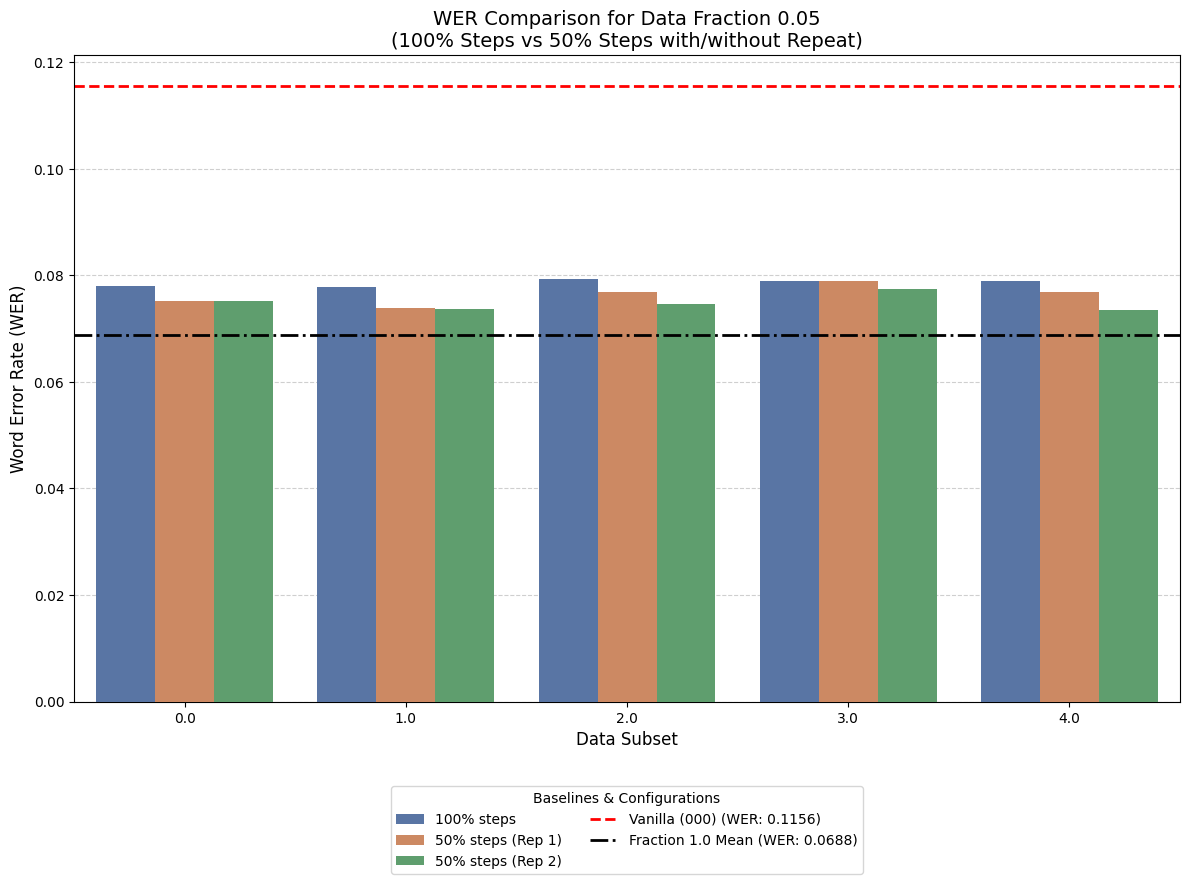

In [8]:
plot_wer_bar_chart(df)

In [15]:
def plot_wer_summary_chart(df):
    """
    Plots a summarized bar chart of WER for fraction 0.05.
    Groups results into 3 bars: 100% steps, 50% steps (Rep 1), and 50% steps (Rep 2).
    Shows error bars based on standard deviation across all data subsets.
    """
    df_copy = df.copy()
    
    # --- 1. EXTRACT BASELINES FROM FULL DATA ---
    df_copy['fraction_num'] = pd.to_numeric(df_copy['fraction'], errors='coerce')
    df_copy['wer'] = pd.to_numeric(df_copy['wer'], errors='coerce')

    baseline_rows = df_copy[df_copy['experiment_id'] == '000']
    vanilla_wer = baseline_rows['wer'].iloc[0] if not baseline_rows.empty else None
        
    frac_1_rows = df_copy[df_copy['fraction_num'] == 1.0]
    frac_1_mean_wer = frac_1_rows['wer'].mean() if not frac_1_rows.empty else None

    # --- 2. FILTER & CATEGORIZE (0.05 FRACTION) ---
    plot_df = df_copy[df_copy['fraction_num'] == 0.05].copy()
    
    if plot_df.empty:
        print("No data found for fraction 0.05")
        return

    def categorize(row):
        if str(row['steps']) == '100% steps':
            return '100% steps'
        elif str(row['steps']) == '50% steps':
            repeat_val = str(row['is_repeat']).lower().strip()
            if repeat_val == 'no':
                return '50% steps (Rep 1)'
            elif repeat_val == 'yes':
                return '50% steps (Rep 2)'
        return None

    plot_df['experiment_group'] = plot_df.apply(categorize, axis=1)
    plot_df = plot_df.dropna(subset=['experiment_group'])

    # --- 3. CREATE THE PLOT ---
    plt.figure(figsize=(10, 8))
    
    # Use seaborn barplot with errorbar='sd' to show standard deviation
    sns.barplot(
        data=plot_df,
        x='experiment_group',
        y='wer',
        errorbar='sd',
        capsize=0.1,
        palette={
            '100% steps': '#4C72B0',
            '50% steps (Rep 1)': '#DD8452',
            '50% steps (Rep 2)': '#55A868'
        },
    )

    # Add Vanilla (000) and Fraction 1.0 Mean lines
    if vanilla_wer is not None:
        plt.axhline(y=vanilla_wer, color='red', linestyle='--', linewidth=2, label=f"Vanilla (000) (WER: {vanilla_wer:.4f})")
    if frac_1_mean_wer is not None:
        plt.axhline(y=frac_1_mean_wer, color='black', linestyle='-.', linewidth=2, label=f"Fraction 1.0 Mean (WER: {frac_1_mean_wer:.4f})",zorder=4)

    # --- 4. FORMATTING ---
    plt.title('Summary of WER Results (Fraction 0.05)\nMean and SD across all subsets', fontsize=14)
    plt.xlabel('Experiment Configuration', fontsize=12)
    plt.ylabel('Word Error Rate (WER)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6,zorder=1)
    
    plt.legend(title='Baselines', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2078120/158839422.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


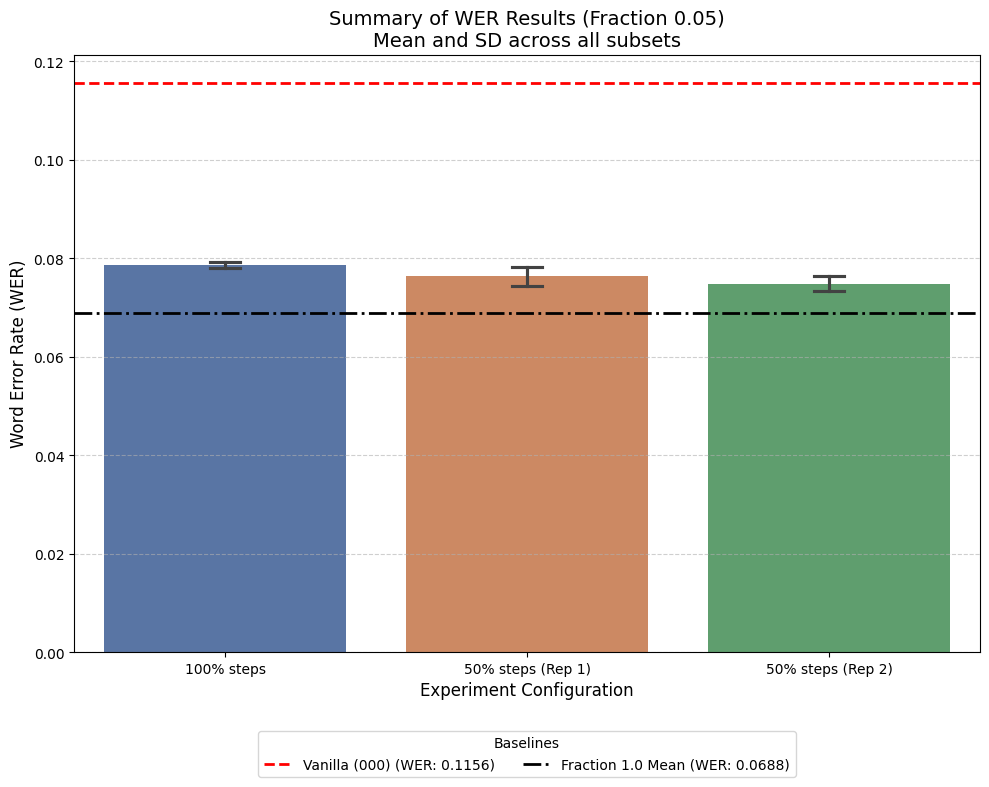

In [16]:
plot_wer_summary_chart(df)

## All Data Scaling results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import re 
from matplotlib.ticker import ScalarFormatter


In [2]:
results_dir = "../outputs/"
all_res_paths = list(Path(results_dir).rglob("results.json"))

In [3]:
metadata = {
    "000": {"label": "Baseline", "type": "baseline"},
    "001": {"label": "L0", "type": "standard"},
    # L0 Experiments (002*)
    "002": {"label": "L0", "type": "lora"},
    "0023": {"label": "L0", "type": "lora"},
    # L1 Experiments (003*) - Skipped
    "0030": {"label": "L1", "type": "standard"},
    "0031": {"label": "L1", "type": "lora"},
    # L2 Experiments (004*)
    "0040": {"label": "L2", "type": "standard"},
    "0041": {"label": "L2", "type": "lora"},
    # L3 Experiments (005*)
    "0050": {"label": "L3", "type": "standard"},
    "0051": {"label": "L3", "type": "lora"},
    # L4 Experiments (006*)
    "0060": {"label": "L4", "type": "standard"},
    "0061": {"label": "L4", "type": "lora"},
    # L5 Experiments (007*)
    "0070": {"label": "L5", "type": "standard"},
    "0071": {"label": "L5", "type": "lora"},
    # L6 Experiments (008*)
    "0080": {"label": "L6", "type": "standard"},
    "0081": {"label": "L6", "type": "lora"},
    "*-d":"Experiemnts with different dropouts"
}

datasets = ["gigaspeech", "spgispeech_2", "voxpopuli"]

accepted_exps_for_data_scaling = [
    "000",
    "001",
    "0023",
    "0030",
    "0031",
    "0040",
    "0041",
    "0050",
    "0051",
    "0060",
    "0061",
    "0070",
    "0071",
    "0080",
    "0081",
]

In [4]:
accepted_set = set(accepted_exps_for_data_scaling)

filtered_paths = [
    path for path in all_res_paths 
    if any(part in accepted_set for part in path.parts)
]
filtered_paths = [path for path in filtered_paths if "half" not in str(path)]
filtered_paths[:5]

[PosixPath('../outputs/voxpopuli/007/0070/0070_frac_1.0_subset_0/results.json'),
 PosixPath('../outputs/voxpopuli/007/0071/0071_frac_1.0_subset_0/results.json'),
 PosixPath('../outputs/voxpopuli/004/0040/0040_frac_1.0_subset_0/results.json'),
 PosixPath('../outputs/voxpopuli/006/0060/0060_frac_1.0_subset_0/results.json'),
 PosixPath('../outputs/voxpopuli/006/0061/0061_frac_1.0_subset_0/results.json')]

In [5]:
pattern = r"^(?:seed_(\d+)_)?.*?_frac_([\d.]+)_subset_(\d+)"
paths = [
    "seed_42_frac_1.0_subset_0",
    "data_scaling_frac_0.1_subset_0"
]
def extract_metadata(path_str):
    # 1. Always get the fraction and subset (The constants)
    core_match = re.search(r"_frac_([\d.]+)_subset_(\d+)", path_str)
    
    # 2. Specifically look for the seed anywhere in the string
    seed_match = re.search(r"seed_(\d+)", path_str)
    
    if core_match:
        return {
            "seed": seed_match.group(1) if seed_match else None,
            "fraction": float(core_match.group(1)),
            "subset": int(core_match.group(2))
        }
    return None

# Test
for p in paths:
    print(extract_metadata(p))

{'seed': '42', 'fraction': 1.0, 'subset': 0}
{'seed': None, 'fraction': 0.1, 'subset': 0}


In [6]:
all_wers_w_fraction = []
for p in filtered_paths:
    path_parts = p.parts
    exp_id = next((part for part in path_parts if part in accepted_set), None)

    path_str = str(p)
    dataset_name = path_str.split("/")[2]

    fraction = None
    subset = None
    core_match = re.search(r"_frac_([\d.]+)_subset_(\d+)", path_str)
    seed_match = re.search(r"seed_(\d+)", path_str)

    if core_match:
        seed = seed_match.group(1) if seed_match else None
        fraction = float(core_match.group(1)) 
        subset = int(core_match.group(2))
    
    loaded_results = json.load(p.open())
    wer = None
    wer_accent = None
    if dataset_name =="voxpopuli":
        wer = loaded_results["metrics"]["voxpopuli-en"]["wer"]
        wer_accent = loaded_results["metrics"]["voxpopuli-en-accented"]["wer"]
    elif fraction !=1 and exp_id not in ["000","001"]:
        if dataset_name == "gigaspeech":
            wer = loaded_results["metrics"]["speechcolab-gigaspeech-m"]["wer"]
        elif dataset_name == "spgispeech_2":
            wer = loaded_results["metrics"]["spgispeech_2"]["wer"]
    else:
        wer = loaded_results["metrics"]["wer"]

    res_w_metadata = {
        "experiemnt_id":exp_id,
        "dataset":dataset_name,
        "fraction": fraction,
        "subset":subset,
        "seed": seed,
        "wer":wer,
        "wer_accent":wer_accent,
        "result_path": p
    }
    all_wers_w_fraction.append(res_w_metadata)
    
all_wers_w_fraction


[{'experiemnt_id': '0070',
  'dataset': 'voxpopuli',
  'fraction': 1.0,
  'subset': 0,
  'seed': None,
  'wer': 0.05875926829835204,
  'wer_accent': 0.2786983180201541,
  'result_path': PosixPath('../outputs/voxpopuli/007/0070/0070_frac_1.0_subset_0/results.json')},
 {'experiemnt_id': '0071',
  'dataset': 'voxpopuli',
  'fraction': 1.0,
  'subset': 0,
  'seed': None,
  'wer': 0.06389605559816842,
  'wer_accent': 0.21016412270302312,
  'result_path': PosixPath('../outputs/voxpopuli/007/0071/0071_frac_1.0_subset_0/results.json')},
 {'experiemnt_id': '0040',
  'dataset': 'voxpopuli',
  'fraction': 1.0,
  'subset': 0,
  'seed': None,
  'wer': 0.07691234920856287,
  'wer_accent': 0.22248258743331356,
  'result_path': PosixPath('../outputs/voxpopuli/004/0040/0040_frac_1.0_subset_0/results.json')},
 {'experiemnt_id': '0060',
  'dataset': 'voxpopuli',
  'fraction': 1.0,
  'subset': 0,
  'seed': None,
  'wer': 0.06261766961857611,
  'wer_accent': 0.2453551052163604,
  'result_path': PosixPath('

In [7]:
df = pd.DataFrame(all_wers_w_fraction)
df.head()

,experiemnt_id,dataset,fraction,subset,seed,wer,wer_accent,result_path
0,0070,voxpopuli,1.0,0.0,None,0.058759,0.278698,../outputs/voxpopuli/007/0070/0070_frac_1.0_su...
1,0071,voxpopuli,1.0,0.0,None,0.063896,0.210164,../outputs/voxpopuli/007/0071/0071_frac_1.0_su...
2,0040,voxpopuli,1.0,0.0,None,0.076912,0.222483,../outputs/voxpopuli/004/0040/0040_frac_1.0_su...
3,0060,voxpopuli,1.0,0.0,None,0.062618,0.245355,../outputs/voxpopuli/006/0060/0060_frac_1.0_su...
4,0061,voxpopuli,1.0,0.0,None,0.066151,0.213591,../outputs/voxpopuli/006/0061/0061_frac_1.0_su...


In [8]:
df_from_rad2 = pd.read_csv("../outputs/voxpopuli_from_rad2.csv",dtype={'experiemnt_id': str})
df_from_rad2.head()

,experiemnt_id,dataset,fraction,subset,wer,wer_accent,result_path
0,0051,voxpopuli,0.2,1,0.075843,0.185245,../outputs/voxpopuli/005/0051/data_scaling/dat...
1,0051,voxpopuli,0.5,0,0.074449,0.172454,../outputs/voxpopuli/005/0051/data_scaling/dat...
2,0051,voxpopuli,0.2,0,0.075797,0.175265,../outputs/voxpopuli/005/0051/data_scaling/dat...
3,0051,voxpopuli,0.1,0,0.076052,0.184545,../outputs/voxpopuli/005/0051/data_scaling/dat...
4,0051,voxpopuli,0.1,2,0.076471,0.186000,../outputs/voxpopuli/005/0051/data_scaling/dat...


In [9]:
df_all_exps = pd.concat([df,df_from_rad2], ignore_index=True)
df_all_exps.tail()  

,experiemnt_id,dataset,fraction,subset,seed,wer,wer_accent,result_path
143,0081,voxpopuli,0.5,0.0,NaN,0.064384,0.199462,../outputs/voxpopuli/008/0081/data_scaling/dat...
144,0081,voxpopuli,0.2,0.0,NaN,0.067150,0.190089,../outputs/voxpopuli/008/0081/data_scaling/dat...
145,0081,voxpopuli,0.1,0.0,NaN,0.068614,0.187509,../outputs/voxpopuli/008/0081/data_scaling/dat...
146,0081,voxpopuli,0.1,2.0,NaN,0.078121,0.186671,../outputs/voxpopuli/008/0081/data_scaling/dat...
147,0081,voxpopuli,0.1,1.0,NaN,0.068847,0.182244,../outputs/voxpopuli/008/0081/data_scaling/dat...


In [10]:
df_metadata = pd.DataFrame(metadata).T.reset_index().rename(columns={"index": "experiemnt_id"})
df_metadata

,experiemnt_id,label,type
0,000,Baseline,baseline
1,001,L0,standard
2,002,L0,lora
3,0023,L0,lora
4,0030,L1,standard
5,0031,L1,lora
6,0040,L2,standard
7,0041,L2,lora
8,0050,L3,standard
9,0051,L3,lora


In [11]:
df_final = pd.merge(df_all_exps,df_metadata,on="experiemnt_id",how="left")
df_final.tail()

,experiemnt_id,dataset,fraction,subset,seed,wer,wer_accent,result_path,label,type
143,0081,voxpopuli,0.5,0.0,NaN,0.064384,0.199462,../outputs/voxpopuli/008/0081/data_scaling/dat...,L6,lora
144,0081,voxpopuli,0.2,0.0,NaN,0.067150,0.190089,../outputs/voxpopuli/008/0081/data_scaling/dat...,L6,lora
145,0081,voxpopuli,0.1,0.0,NaN,0.068614,0.187509,../outputs/voxpopuli/008/0081/data_scaling/dat...,L6,lora
146,0081,voxpopuli,0.1,2.0,NaN,0.078121,0.186671,../outputs/voxpopuli/008/0081/data_scaling/dat...,L6,lora
147,0081,voxpopuli,0.1,1.0,NaN,0.068847,0.182244,../outputs/voxpopuli/008/0081/data_scaling/dat...,L6,lora


In [12]:
# df_final.to_excel("/mnt/asr-data-scaling/outputs/all_exps_final.xlsx",index=False)

In [13]:
# def prepare_data(df, target_dataset):
#     """Filters data by dataset and creates the 3 specific DataFrames needed."""
#     # 1. Filter by dataset
#     df_filtered = df[df['dataset'] == target_dataset].copy()
    
#     # 2. Extract LoRA and aggregate mean & std
#     lora_df = df_filtered[df_filtered['type'] == 'lora']
#     lora_agg = lora_df.groupby(['label', 'fraction'])['wer'].agg(['mean', 'std']).reset_index()
    
#     # 3. Extract the baselines (000 and 001)
#     base_000_df = df_filtered[df_filtered['experiemnt_id'] == '000']
#     base_001_df = df_filtered[df_filtered['experiemnt_id'] == '001']
    
#     return lora_agg, base_001_df, base_000_df

In [14]:
def prepare_data(df, target_dataset):
    """Filters data by dataset and creates the 2 specific DataFrames needed."""
    
    # 1. Initial filter by dataset (Create the variable before using it!)
    df_filtered = df[df['dataset'] == target_dataset].copy()
    
    if df_filtered.empty:
        print(f"Warning: No data found for dataset {target_dataset}")
        return pd.DataFrame(), pd.DataFrame()

    # 2. Apply the Seed Filter
    # We use fillna or string conversion to handle None/NaN and '42' safely
    df_filtered = df_filtered[
        (df_filtered['seed'].isna()) | 
        (df_filtered['seed'].astype(str) == '42')
    ].copy()

    # 3. Extract LoRA and aggregate mean & std
    lora_df = df_filtered[df_filtered['type'] == 'lora'].copy()
    
    if not lora_df.empty:
        # We group by label and fraction, keeping the first 'exp_id' for the title
        lora_agg = lora_df.groupby(['label', 'fraction']).agg({
            'wer': ['mean', 'std'],
            'experiemnt_id': 'first' 
        }).reset_index()
        
        # Flatten columns from the .agg() call
        lora_agg.columns = ['label', 'fraction', 'mean', 'std', 'exp_id']
    else:
        lora_agg = pd.DataFrame()

    # 4. Extract Standard Finetuning (Note: Check spelling of experiment_id)
    # Using .astype(str) ensures '001' doesn't fail if the CSV loaded it as the number 1
    base_001_df = df_filtered[df_filtered['experiemnt_id'].astype(str) == '001'].copy()
    
    return lora_agg, base_001_df

In [21]:
import matplotlib.pyplot as plt

def plot_wer_experiments(df, target_dataset):
    lora_agg, base_001_df = prepare_data(df, target_dataset)
    labels = lora_agg['label'].dropna().unique()
    num_labels = len(labels)
    
    if num_labels == 0: return

    # 1. Extract global baseline
    baseline_val = None
    if not base_001_df.empty:
        l0_base = base_001_df[base_001_df['label'] == 'L0']
        baseline_val = l0_base['wer'].iloc[0] if not l0_base.empty else base_001_df['wer'].iloc[0]

    num_cols = 2
    num_rows = (num_labels + 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 4 * num_rows + 1), sharex=True)
    axes_flat = axes.flatten()
    
    unique_fractions = sorted(lora_agg['fraction'].unique())
    handles, plot_labels = [], []

    for i, current_label in enumerate(labels):
        ax = axes_flat[i]
        lora_subset = lora_agg[lora_agg['label'] == current_label].sort_values('fraction')
        
        # --- NEW: GET EXPERIMENT ID ---
        # Assuming the column name is 'exp_id'. Change this to your actual column name.
        if 'experiemnt_id' in lora_subset.columns:
            exp_ids = lora_subset['experiemnt_id'].unique()
            # exp_str = f" | ID: {', '.join(map(str, exp_ids))}"
        else:
            exp_str = ""
        # ------------------------------
        exp_id = next((k for k, v in metadata.items() if v['label'] == current_label), None)
        # exp_str = f" | ID: {exp_id}"

        # Plot LoRA
        line1, = ax.plot(lora_subset['fraction'], lora_subset['mean'], 
                         label='LoRA (Mean)', marker='o', color='#0044BB', linewidth=2)
            
        # Plot Baseline
        line2 = None
        if baseline_val is not None:
            line2 = ax.axhline(y=baseline_val, label='Standard FT', 
                               linestyle='--', color='#FF8800', linewidth=2, zorder=3)

        # Dynamic Y-Axis Scaling
        y_values = lora_subset['mean'].tolist()
        if baseline_val is not None: y_values.append(baseline_val)
        if y_values:
            y_min, y_max = min(y_values), max(y_values)
            padding = (y_max - y_min) * 0.15 if (y_max - y_min) > 0 else 0.05
            ax.set_ylim(y_min - padding, y_max + padding)

        # X-Axis Formatting
        ax.set_xticks(unique_fractions)
        ax.set_xticklabels([f"{f}" for f in unique_fractions])
        
        # Only label the bottom row
        if i >= (num_rows - 1) * num_cols:
            ax.set_xlabel('Fraction of Data', fontsize=11)

        # UPDATED TITLE: Includes Experiment ID
        ax.set_title(f'Layers Involved: {current_label}{exp_str}', fontsize=12, fontweight='bold')
        
        ax.set_ylabel('WER')
        ax.grid(True, linestyle=':', alpha=0.6)

        if i == 0:
            handles = [line1, line2] if line2 else [line1]
            plot_labels = [h.get_label() for h in handles]

    # Hide extra empty subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    # Shared Legend at the bottom
    fig.legend(handles, plot_labels, loc='upper center', 
               bbox_to_anchor=(0.5, 0.05), ncol=2, fontsize=12, 
               frameon=True, shadow=True)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

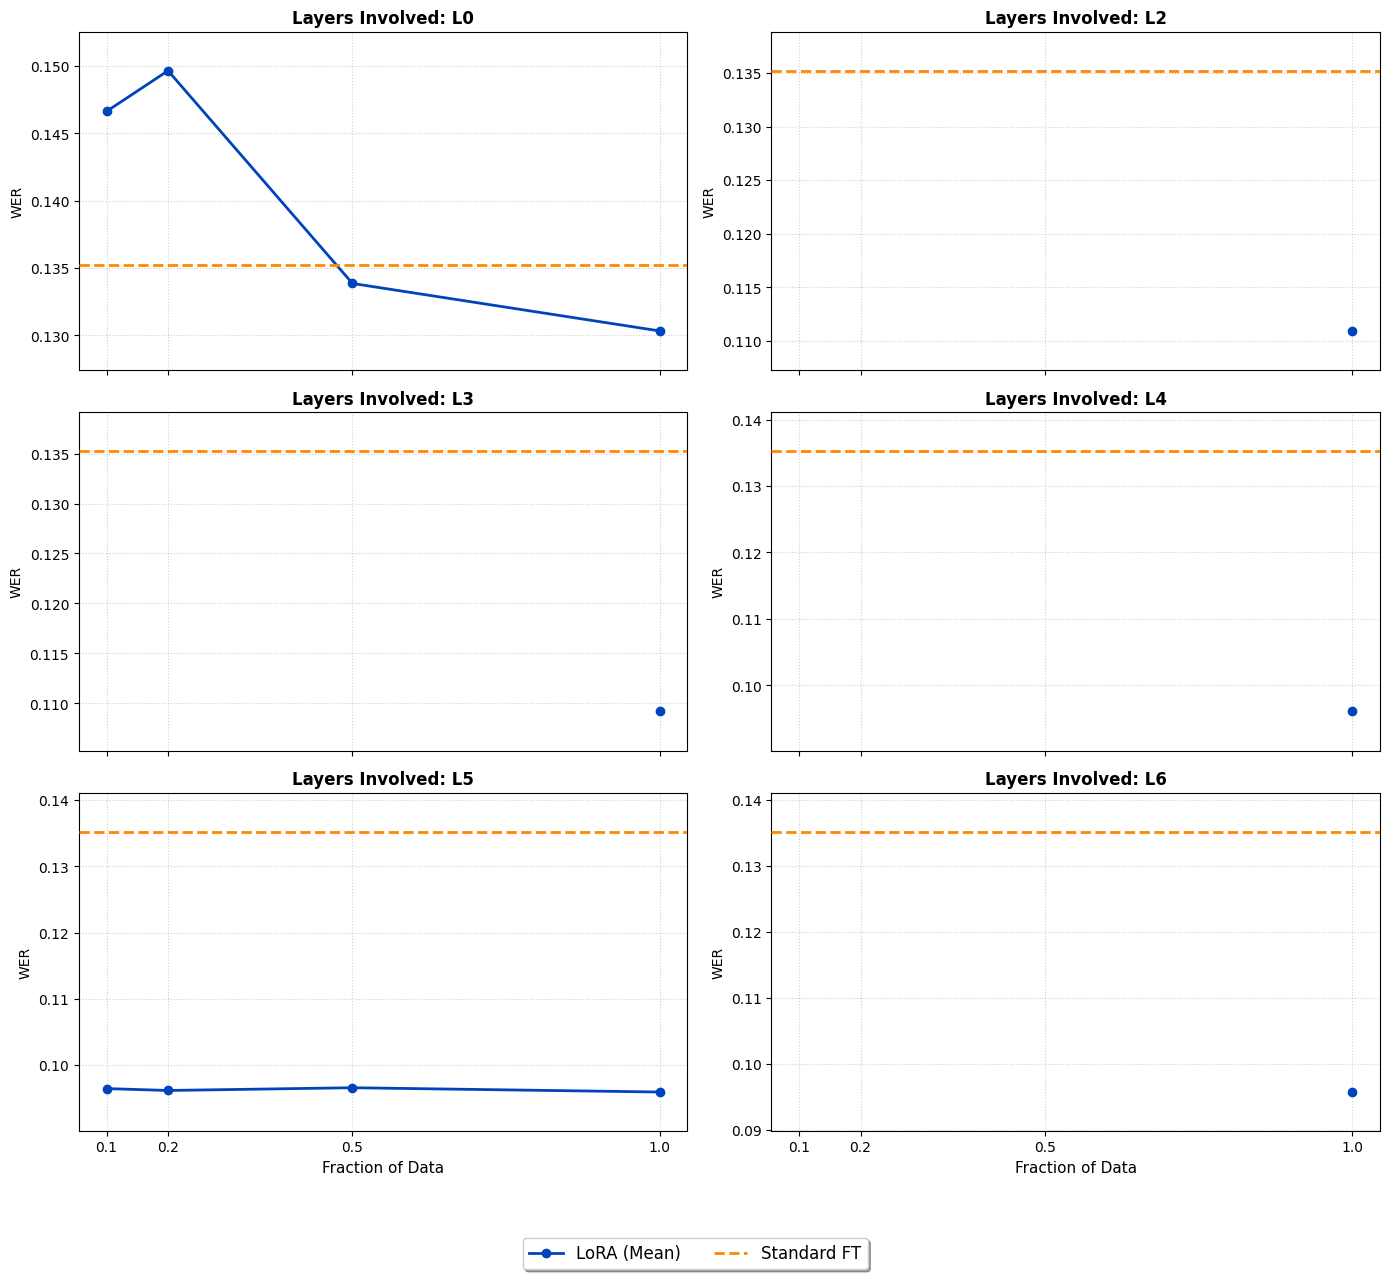

In [24]:
lora_agg, base_001_df= prepare_data(df_final,"gigaspeech")
plot_wer_experiments(df_final,"gigaspeech")


## Investigating optimisation steps discripancy

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import re
import seaborn as sns

In [10]:
def parse_asr_results(file_path):
    path = Path(file_path)
    
    with open(path, 'r') as f:
        data = json.load(f)
    
    # Improved WER extraction
    metrics = data.get("metrics", {})
    wer = None
    
    if metrics:
        # Get the first value in the metrics dict (e.g., 'speechcolab-gigaspeech-m')
        first_val = list(metrics.values())[0]
        
        # If the value is a dict, get 'wer' from it. 
        # If it's already a float (unlikely based on your example, but safe), use it.
        if isinstance(first_val, dict):
            wer = first_val.get("wer")
        else:
            wer = first_val

    path_str = str(path)
    
    # Updated Regex to handle the new path format you provided: 
    # .../0041/0041_frac_1.0_subset_0_old/results.json
    
    # 1. Dataset Name
    dataset_name = "gigaspeech" if "gigaspeech" in path_str else ("spgispeech_2" if "spgispeech_2" in path_str else "voxpopuli")
    
    # 2. Experiment ID - Look for the 4 digits after a slash
    exp_id_match = re.search(r'/(\d{4})/', path_str)
    exp_id = exp_id_match.group(1) if exp_id_match else None
    
    # 3. Data Fraction - Handles both 'frac_0.1' and 'frac_1.0'
    frac_match = re.search(r'frac_([\d.]+)', path_str)
    data_fraction = float(frac_match.group(1)) if frac_match else None
    
    # 4. Training Logic
    is_old = "_old" in path_str
    training_regime = "data_frac_steps" if is_old else "full_dataset_steps"

    return {
        "dataset": dataset_name,
        "experiment_id": exp_id,
        "data_fraction": data_fraction,
        "wer": wer,
        "is_old_regime": is_old,
        "training_logic": training_regime
    }

In [31]:
seletced_paths = "/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081"
all_res_paths = list(Path(seletced_paths).rglob("results.json"))
exclude_list = ["0.05", "half", "123_","1234_", "123456_", "42_"]
all_res_paths = [
    path for path in all_res_paths 
    if not any(exclude in str(path) for exclude in exclude_list)
]
all_res_paths

[PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/0081_frac_1.0_subset_0_old/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.1_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.1_subset_2/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.5_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.2_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.5_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.1_subset_0/results.json'),
 PosixPath('/mnt/asr-data

In [32]:
all_res = []
for p in all_res_paths:
    res = parse_asr_results(str(p))
    all_res.append(res)

In [33]:
df = pd.DataFrame(all_res).sort_values(["training_logic","data_fraction"])
mask = df['data_fraction'] == 1.0

# 2. Get the valid WER (filtering out 'False' or boolean noise)
# We convert to numeric so we can safely find the minimum
valid_wer = pd.to_numeric(df.loc[mask, 'wer'], errors='coerce').min()

# 3. Update both 'wer' and 'is_old_regime' to this value for those rows
df.loc[mask, ['wer', 'is_old_regime']] = valid_wer
df

/tmp/ipykernel_1063953/2291529175.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0487203389166659' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[mask, ['wer', 'is_old_regime']] = valid_wer


,dataset,experiment_id,data_fraction,wer,is_old_regime,training_logic
9,spgispeech_2,0081,0.1,0.051836,True,data_frac_steps
10,spgispeech_2,0081,0.1,0.054149,True,data_frac_steps
13,spgispeech_2,0081,0.1,0.052726,True,data_frac_steps
11,spgispeech_2,0081,0.2,0.052208,True,data_frac_steps
14,spgispeech_2,0081,0.2,0.053167,True,data_frac_steps
12,spgispeech_2,0081,0.5,0.051583,True,data_frac_steps
0,spgispeech_2,0081,1.0,0.048720,0.04872,data_frac_steps
1,spgispeech_2,0081,0.1,0.083069,False,full_dataset_steps
2,spgispeech_2,0081,0.1,0.082265,False,full_dataset_steps
7,spgispeech_2,0081,0.1,0.081039,False,full_dataset_steps


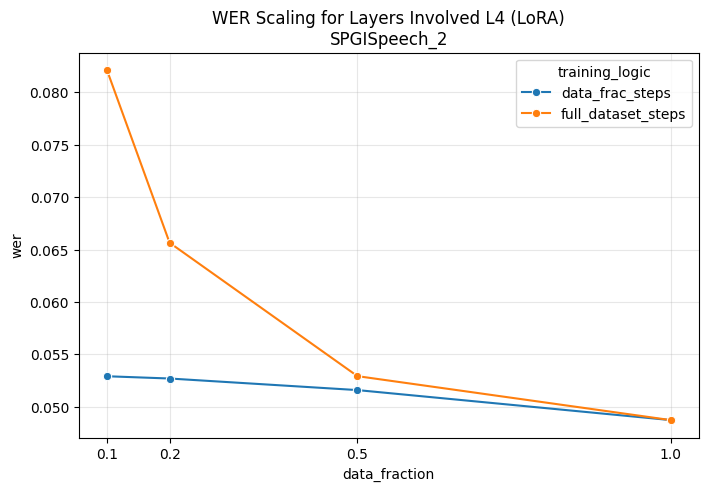

In [34]:
unique_fractions = sorted(df['data_fraction'].unique())
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='data_fraction', y='wer', hue='training_logic', marker='o',errorbar=None)

# Force the x-axis to only show these specific "distinct" numbers
plt.xticks(unique_fractions)

plt.title("WER Scaling for Layers Involved L4 (LoRA)\nSPGISpeech_2")
plt.grid(alpha=0.3)
plt.show()